# Data visualization: periodic table

In this notebook, we will generate several visualizations for the periodic table dataset. This code aims to provide readers with an overview of possible graphs that can be created with simple data.

To start the data exploration, we first load the dataset using `pandas` and visualize its first entries: 

In [1]:
try:
    import google.colab
    IN_COLAB = True
    !git clone https://github.com/dskoda/ml4mat-26s-public.git
    !cd ml4mat-26s-public && pip install . && cd ..
    ROOT = "https://github.com/dskoda/ml4mat-26s-public/raw/lectures/01-DataScience"
    STYLE = "colab"
except:
    IN_COLAB = False
    ROOT = "."
    STYLE = "jupyter"

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ml4mat_ucla as m4m

plt.style.use(STYLE)
m4m.utils.set_dpi(200)

In [3]:
df = pd.read_csv(f"{ROOT}/data/ptable.csv")

In [5]:
df.columns

Index(['AtomicNumber', 'Element', 'Symbol', 'AtomicMass', 'NumberofNeutrons',
       'NumberofProtons', 'NumberofElectrons', 'Period', 'Group', 'Phase',
       'Radioactive', 'Natural', 'MetallicProperty', 'Type', 'AtomicRadius',
       'Electronegativity', 'FirstIonization', 'Density', 'MeltingPoint',
       'BoilingPoint', 'NumberOfIsotopes', 'Discoverer', 'Year',
       'SpecificHeat', 'NumberofShells', 'NumberofValence'],
      dtype='object')

# Data description

The columns indicate that there are several properties available for our use in this tutorial. The data attributes fall within the four data types as follows:

- *Categorical:* element, symbol, phase, radioactive, natural, metallic property, type, discoverer
- *Ordinal:* period, group
- *Quantitative (interval):* year of discovery.
- *Quantitative (ratio):* atomic number, number of neutrons/protons/electrons, number of isotopes/shells/valence, atomic mass, atomic radius, electronegativity, first ionization energy, density, melting point, boiling point, specific heat

The period and group could be considered quantitative (interval) data points too. Because they are labeled with numbers and there is a clear physical definition of what it takes to increase/decrease the group/period number (add or remove electrons), one could argue that quantitative (interval) is more appropriate for these properties. Prior to this electronic interpretation, however, the only prior knowledge available for Mendeleev and others was the mass and a few properties. Hence, groups could be called from their representative element ("triad" of oxygen, nitrogen etc.), families (chalcogenides, halides etc.) and so on. This resembles more of a categorical data than quantitative. It is only by defining a metric of ordering that one can transform these categorical labels in ordinal ones (e.g., halides are heavier than their chalcogenide counterparts).

Using this information, we can proceed to explore a few visualizations for the data.

# One-dimensional plots

One-dimensional plots are useful for visualizing the distribution of data points. In these plots, only one quantitative variable is considered at once. Ordinal and categorical variables can be used as well, and the final graph will contain categorical and quantitative metrics at once. Below, we show several examples on how these can be constructed.

## Strip plot

A strip plot is the simplest possible graph to indicate the distribution of data points according to one quantitative metric. Below, one marker is plotted for each element discovered.

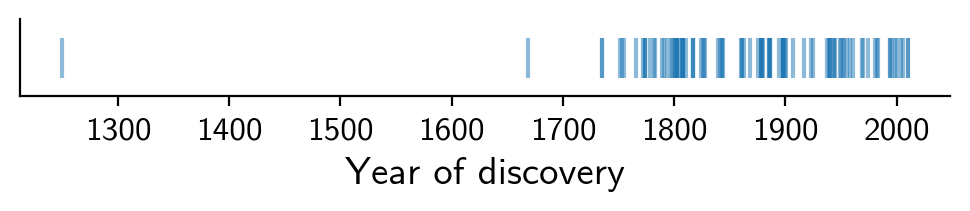

In [6]:
fig, ax = plt.subplots(figsize=(6, .5))

x = df['Year'].values
y = np.zeros_like(x)

ax.scatter(x, y, s=200, marker='|', alpha=0.5)
ax.set_yticks([])
ax.set_xlabel('Year of discovery')

plt.show()

Despite its simplicity, the strip plot is typically not used. As the markers overlap in the one-dimensional representation, it is harder to visualize how many points fall within certain ranges of years. One option to address this issue is to add a bit of noise to the location of the markers such that the overlap is reduced. This so-called jitter plot aids with the visualization of overlapping data without increasing the complexity of the representation:

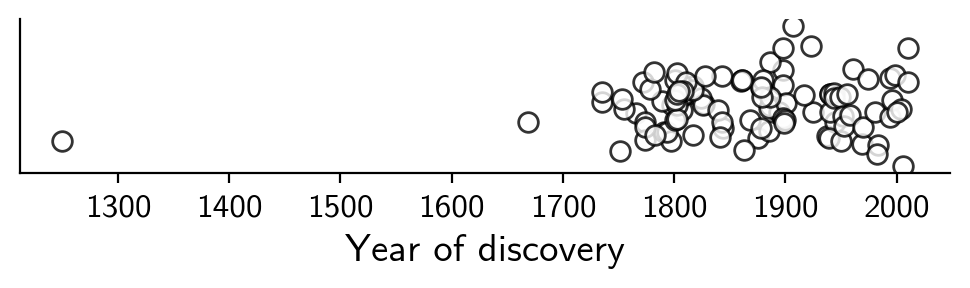

In [7]:
fig, ax = plt.subplots(figsize=(6, 1))

x = df['Year'].values
y = 10 * np.random.randn(x.size)

ax.scatter(x, y, s=50, marker='o', facecolor='#ffffff00', edgecolor='k', alpha=0.8)
ax.set_yticks([])
ax.set_xlabel('Year of discovery')

plt.show()

This plot already shows that the beginning and end of the 1800's, and the middle of the 20th century were among the most prolific times in the discovery of new elements. Indeed, in the 1940's and 1950's, several new elements were discovered due to experiments with radiation. We could obtain that insight by plotting the strip plot using the period of the element as an ordinal variable:

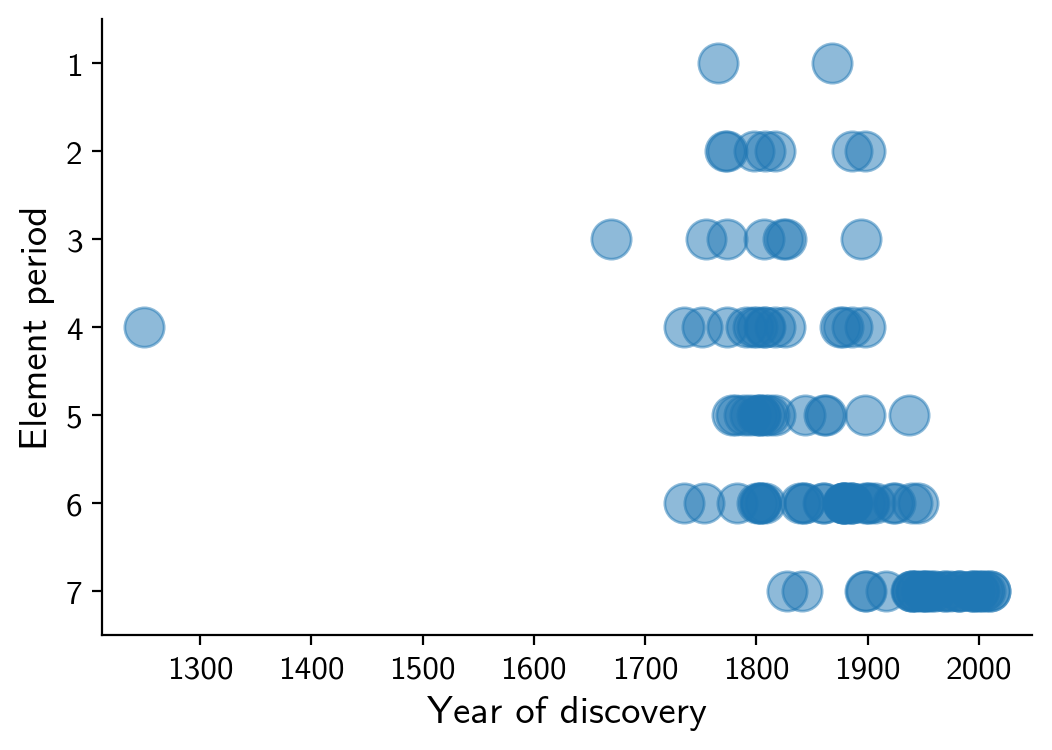

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))

x = df['Year'].values
y = df['Period'].values

ax.scatter(x, y, s=200, marker='o', alpha=0.5)

ax.set_xlabel('Year of discovery')
ax.set_ylabel('Element period')

ax.set_ylim(y.max() + 0.5, y.min() - 0.5)

plt.show()

The plot already suggests that later elements were indeed discovered at a later date. Please note the deliberate choice of y axis for this visualization. Because of the convention of the periodic table, where periods increase downwards, the axis was reversed to conform to this standard.

The same plot could be performed with a true categorical variable such as the most stable phase of matter of the element:

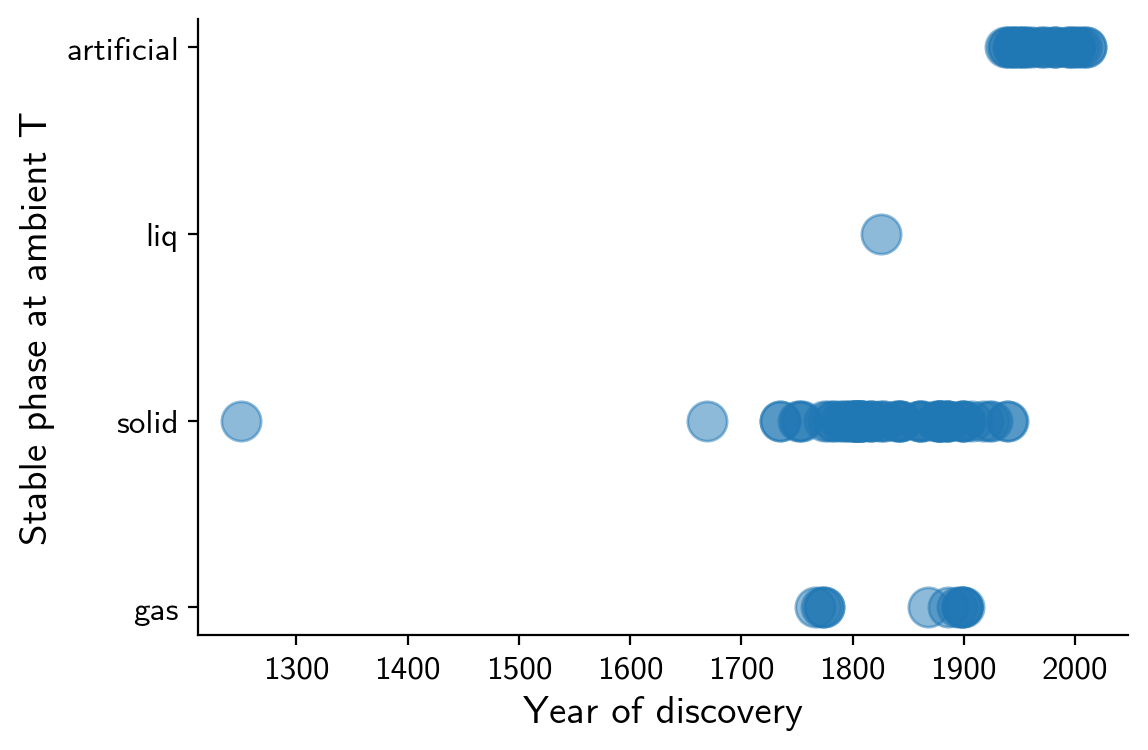

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))

x = df['Year'].values
y = df['Phase'].values

ax.scatter(x, y, s=200, marker='o', alpha=0.5)

ax.set_xlabel('Year of discovery')
ax.set_ylabel('Stable phase at ambient T')

plt.show()

In the plot above, it is evident that artificial elements were discovered only after the 1900's. Hg is the only element of the periodic table whose most stable form is liquid.

## Histograms

Although the strip plots are useful to detect outliers or obtain an overview of the dataset, it does not always help with quantitative information. Within one-dimensional visualizations, one way to bypass this problem is to create histograms, which aggregates the quantitative metric into another quantitative information, usually of density of points.

We can redraw the examples above using histograms:

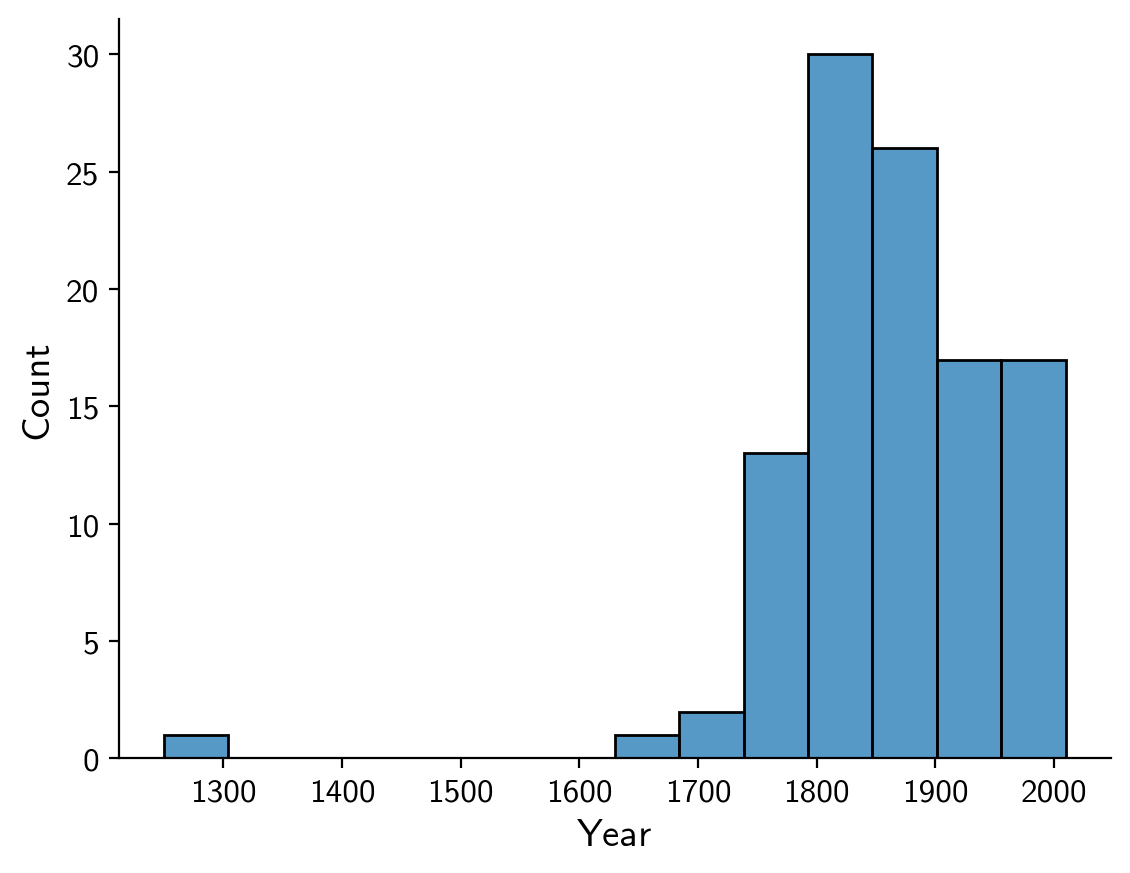

In [10]:
sns.histplot(data=df, x='Year')

plt.show()

With this histograms, it is much more straightforward to see that the most prolific half century for the discovery of elements was between 1800-1850. This also enables a quantitative comparison between the number of elements discovered over time, which was lacking in the strip plot. If we add a categorical variable as before, we can obtain a series of histograms superimposed in the same graph:

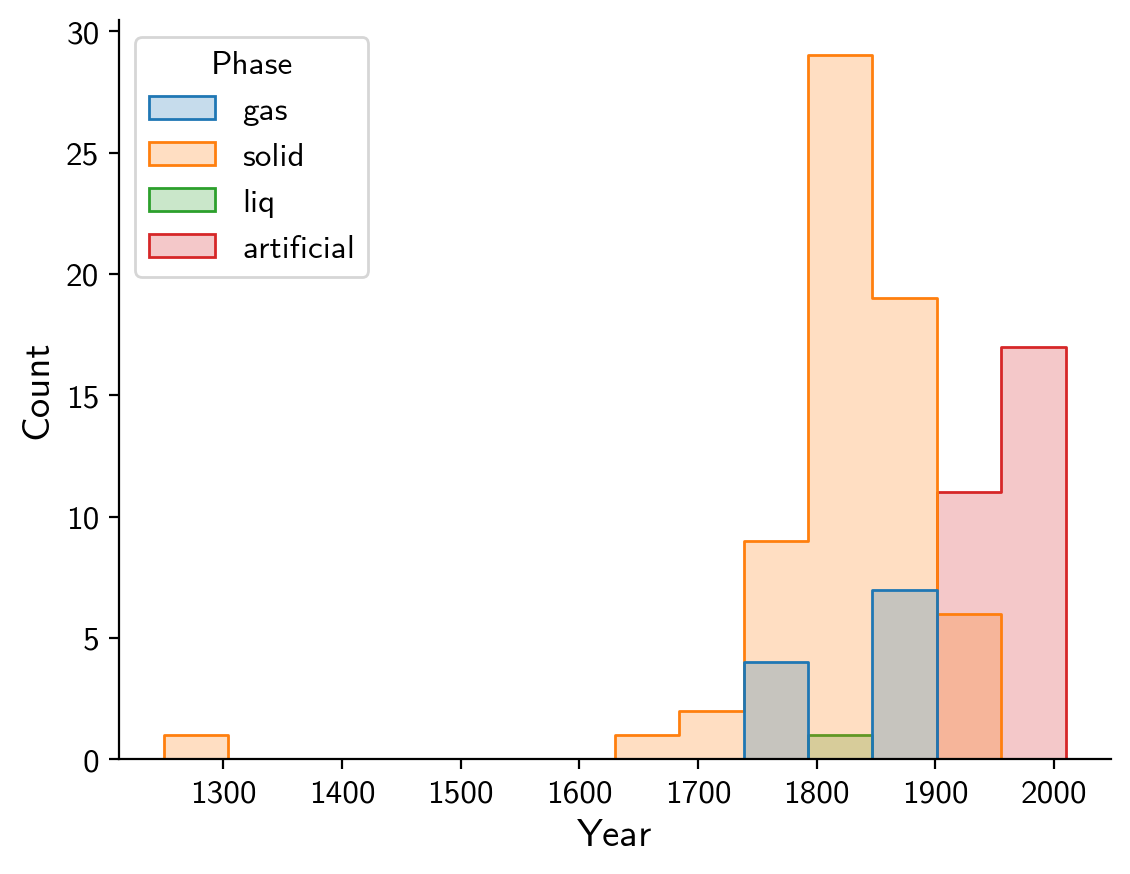

In [11]:
sns.histplot(data=df, x='Year', hue='Phase', element='step')

plt.show()

Often, however, the overlap between histograms can be confusing. One option to better visualize these graphs is to stack the bars of the histogram. This approach is interesting because for each interval, the histogram will give an idea of the total number of discoveries, as well as the breakdown per category:

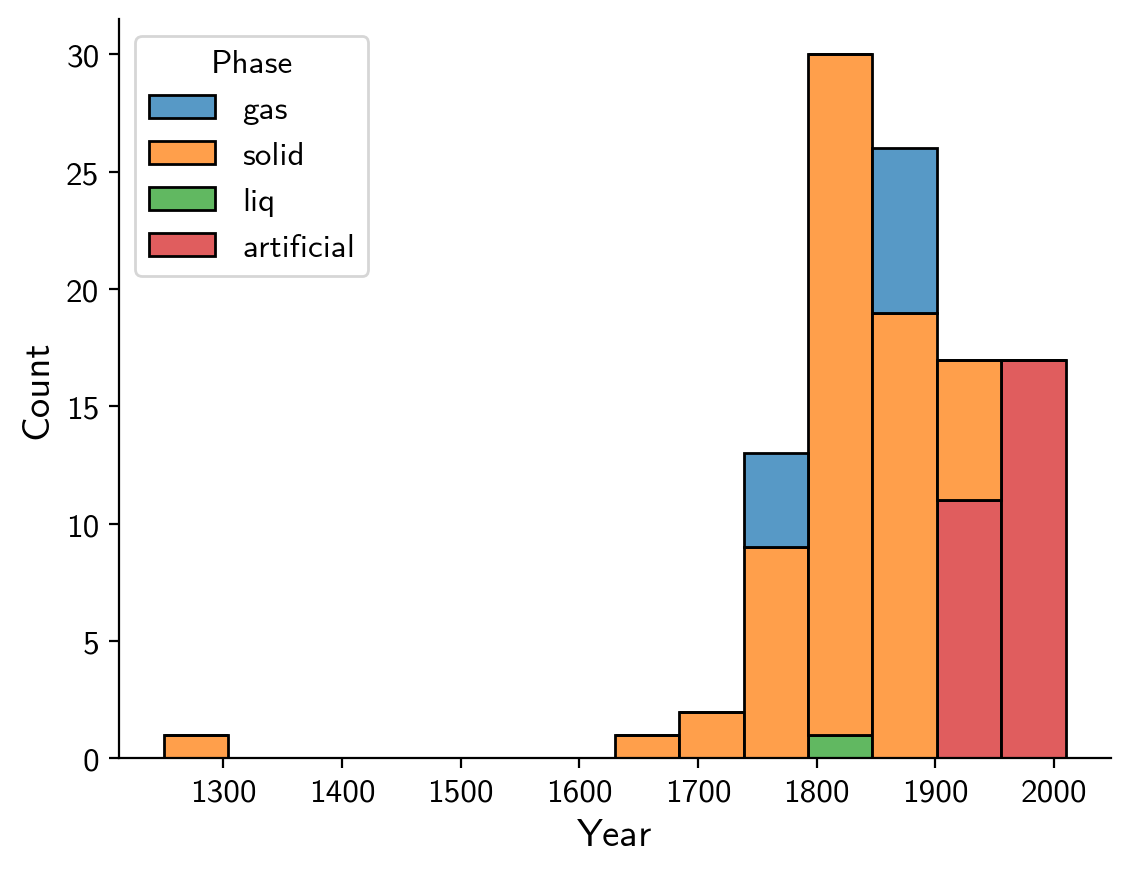

In [12]:
sns.histplot(data=df, x='Year', hue='Phase', multiple='stack')

plt.show()

The histogram above is much more efficient in communicating that most discoveries of the 20th century were of artificial elements, and that there was a gap of at least 50 years between gaseous elements were discovered.

Instead of looking only at the discovery years, however, histograms already enable better analyses to be made with other properties. For example, we could be interested in discovering what are the distributions of densities of pure materials:

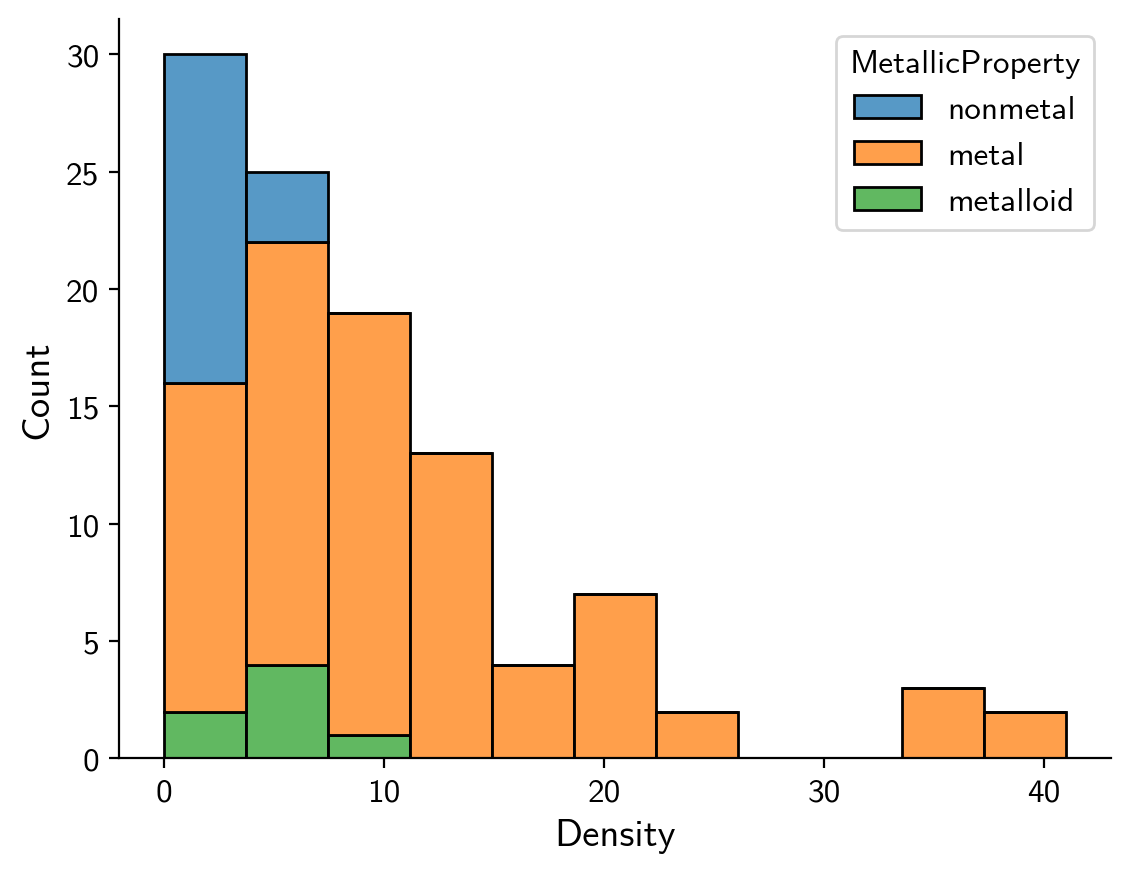

In [13]:
sns.histplot(data=df, x='Density', hue='MetallicProperty', multiple='stack')

plt.show()

The plot above shows that denser phases are metals, and metalloids and non-metals are often less dense. Another example is the melting point according to the phase:

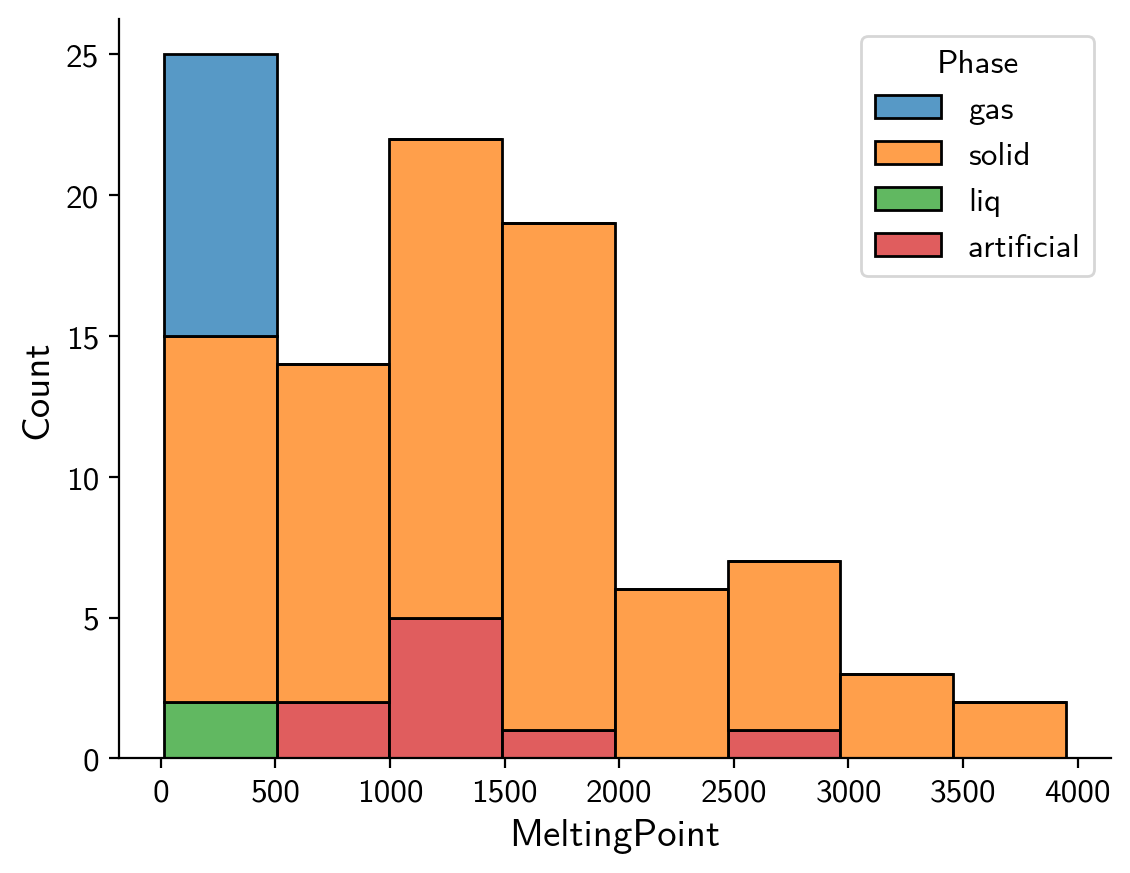

In [14]:
sns.histplot(data=df, x='MeltingPoint', hue='Phase', multiple='stack')

plt.show()

## Distribution plots

Histograms split the data into bins, then aggregate the number of data points that fall within the bins. For many purposes, however, approximating the probability distribution of points is performed better with a smooth function. In these cases, a Kernel Density Estimate (KDE) can be fitted to the data. With an adequate choice of kernel and bandwidth, one can obtain a function that best approximates the data. For example, the plots above can be compared by plotting a KDE and a histogram in the same graph:

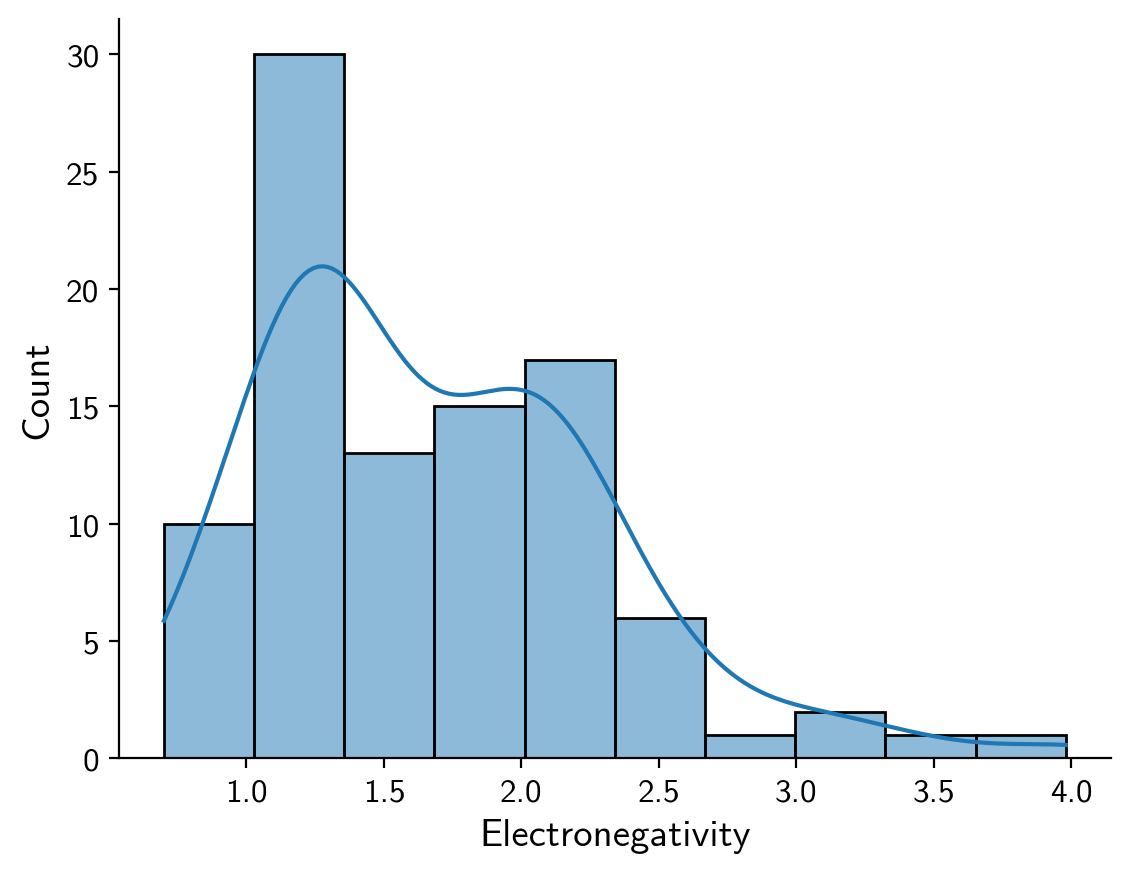

In [15]:
sns.histplot(data=df, x='Electronegativity', kde=True, kde_kws={"bw_adjust": 1.0})

plt.show()

The smooth function can provide some advantages, such as more ease to find peaks in the distribution of points (provided a reasonable choice of bandwidth), and ease of visual comparison to theoretical probability distributions.

### Violin plots

If we wanted to compare how does the electronegativity of pure elements change with their metallicity, we could try plotting the three distributions in the same graph:

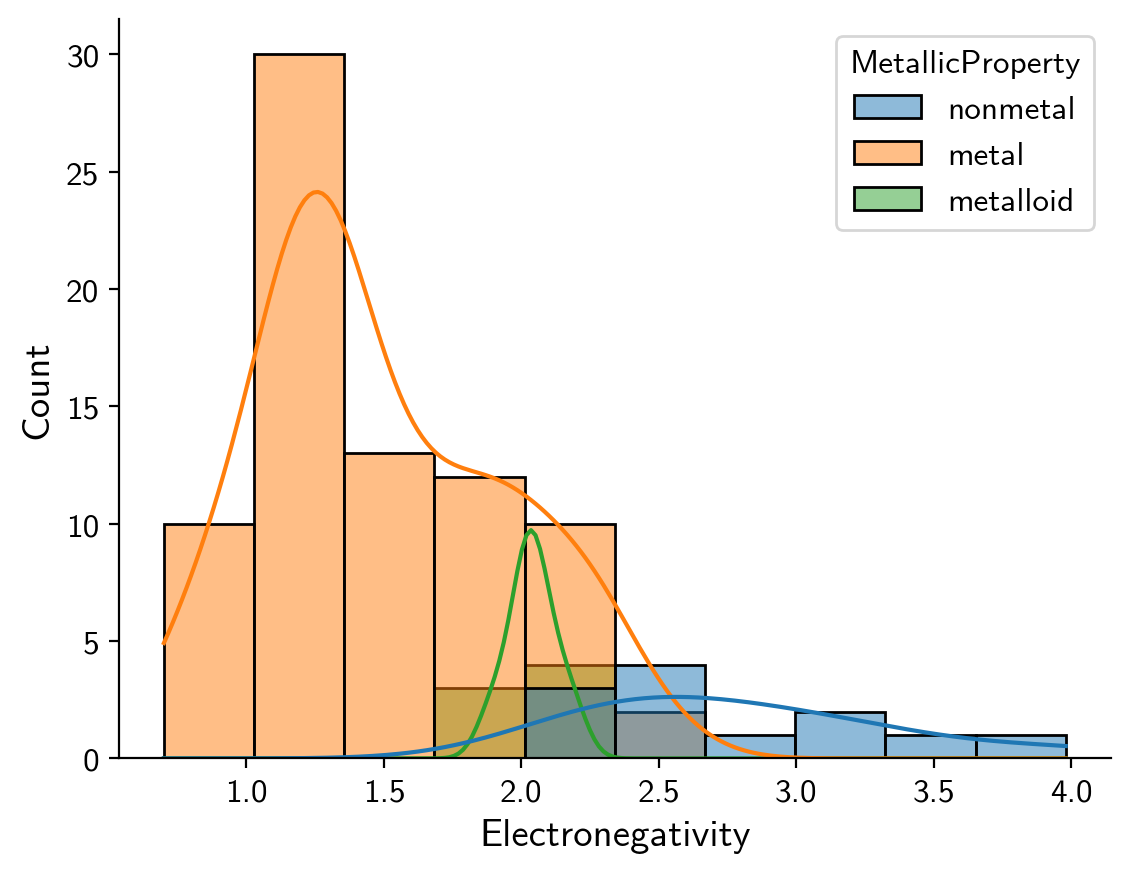

In [16]:
sns.histplot(data=df, x='Electronegativity', hue='MetallicProperty', kde=True)

plt.show()

However, as shown in the example above, the graph can quickly become difficult to visualize due to overlapping distributions or differences in the y axis. One can use the concept of [small multiples](https://en.wikipedia.org/wiki/Small_multiple) to construct a better visualization for the distributions:

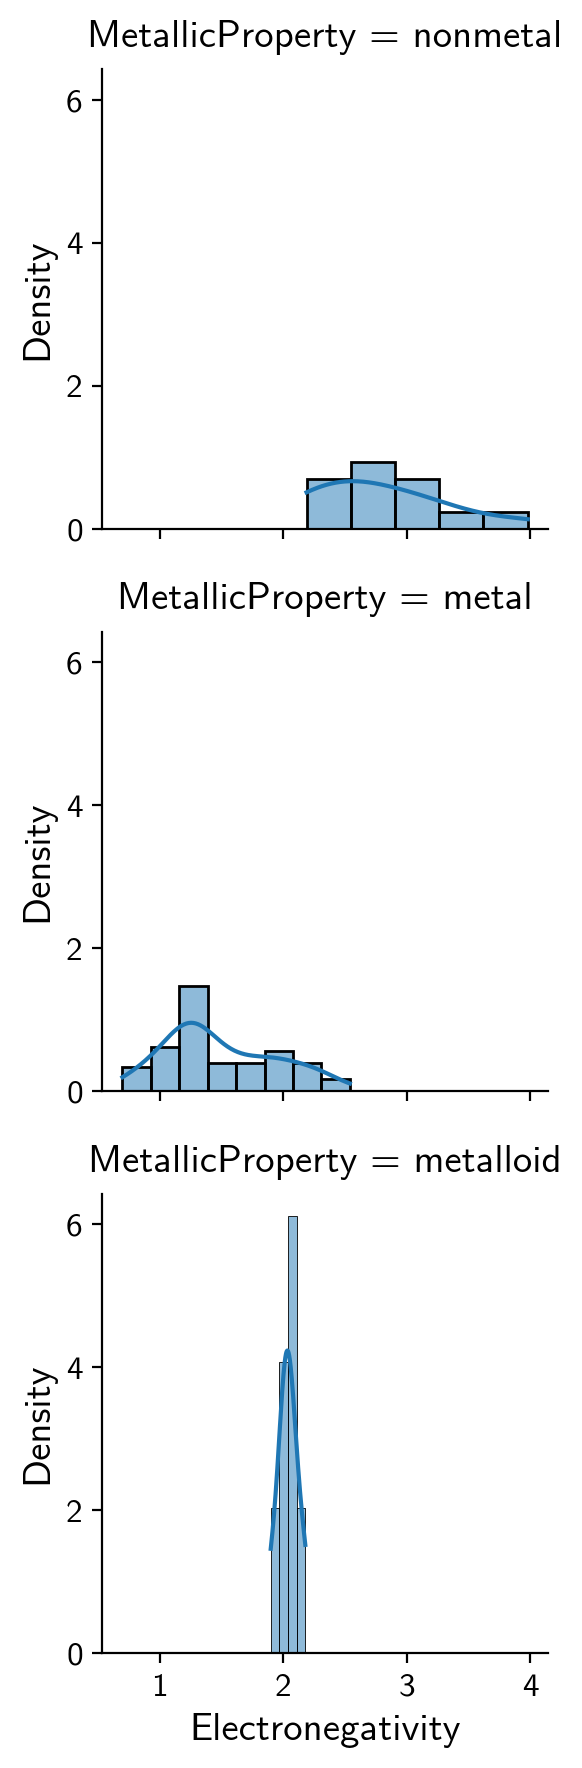

In [17]:
g = sns.FacetGrid(df, row='MetallicProperty')
g.map(sns.histplot, 'Electronegativity', kde=True, stat='density')
plt.show()

The graph above enables more clear comparisons to be made between different distributions, especially when the histograms are normalized to exhibit the density of points. In research, analyzing differences between distributions is often related to [hypothesis testing](https://en.wikipedia.org/wiki/Statistical_hypothesis_testing), which is paramount to determine the statistical significance of certain conclusions.

Especially when multiple distributions are concerned, visualizing the main characteristics of the distributions may be more helpful than having access to all details provided by histograms. In this case, a distribution for each category can be plotted using the so-called violin plots:

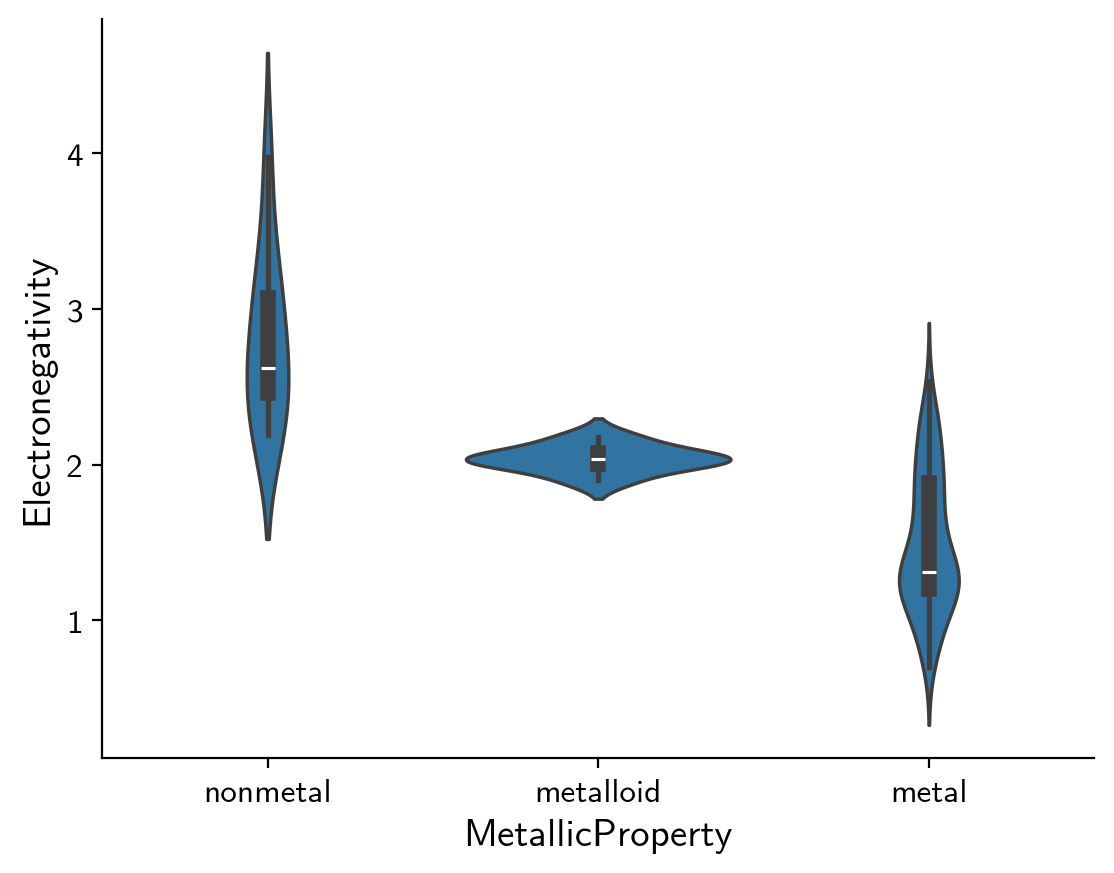

In [18]:
sns.violinplot(
    data=df,
    x='MetallicProperty',
    y='Electronegativity',
    order=['nonmetal', 'metalloid', 'metal'],
)

plt.show()

A violin plot fits a distribution (e.g., through KDE) for each categorical variable. Then, the distribution is plotted with a common axis. In the plots above, the violin shows the fitted distribution (outer lines), range of the distribution (whiskers, thin lines), interquartile range (thick lines), and median (white dot). This allows an immediate comparison of the quantitative variable according to the category. In the example above, it is easier to identify that non-metals have, on average, higher electronegativity than metals, as expected from basic definitions of chemical bonds.

Despite their simplicity, it is important to note a few caveats of using violin plots. Because the distribution is fitted to the sample data, the number of data points may influence the smoothness of the distribution, and even hide this value behind the fitted curves. Furthermore, the fitted distribution may extend beyond the data range. While the whiskers show the exact range of the data distribution, the KDE may go beyond hard limits of the data. In the example above, for example, the distribution of electronegativities for non-metals goes beyond the maximum number of 4 in the Pauling scale.

### Box plots

Although violin plots are informative, the drawbacks mentioned above may render their use innapropriate in a few contexts. A more qualitative description can be created by removing the KDE from the plots above and analyze only the range, interquartile distribution, and median of the data. This approach gives rise to a box plot:

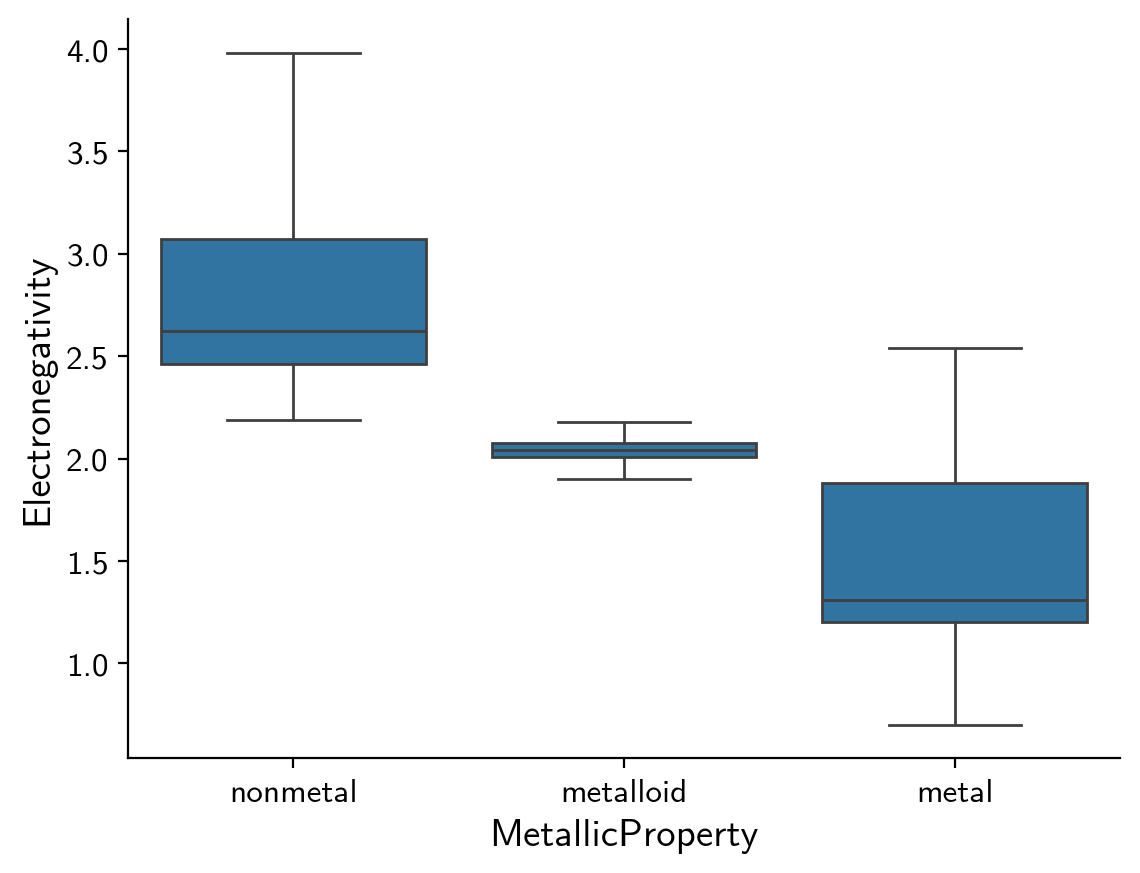

In [19]:
sns.boxplot(
    data=df,
    x='MetallicProperty',
    y='Electronegativity',
    order=['nonmetal', 'metalloid', 'metal'],
    whis=[0, 100],
)

plt.show()

In the plot above, the whiskers represent the range of the distribution, the box is the interquartile ($Q_1 - Q_3$) range, and the horizontal line is the median of the distribution. Again, it is more clear to see that all non-metals have electronegativity higher than more than 75% of the metals. Furthermore, is more clear how metalloids are exactly in-between metals and non-metals in terms of electronegativity, as expected from our chemical knowledge. This representation, which foregoes the KDE, is much more effective in showcasing this property than the violin plot, where the overlap between the distributions makes this insight harder to be extracted.

Although seemingly less informative than violin plots, box plots do not make assumptions on the data distribution. Furthermore, box plots are visually compact and convey intuitions on the statistical significance of the analysis. For these and other reasons, these visualizations tend to be frequently employed in statistical works. Again, however, in the small-data regime, it is not clear how many data points are available for each category. One option to make this clear is to combine a strip plot with a box plot:

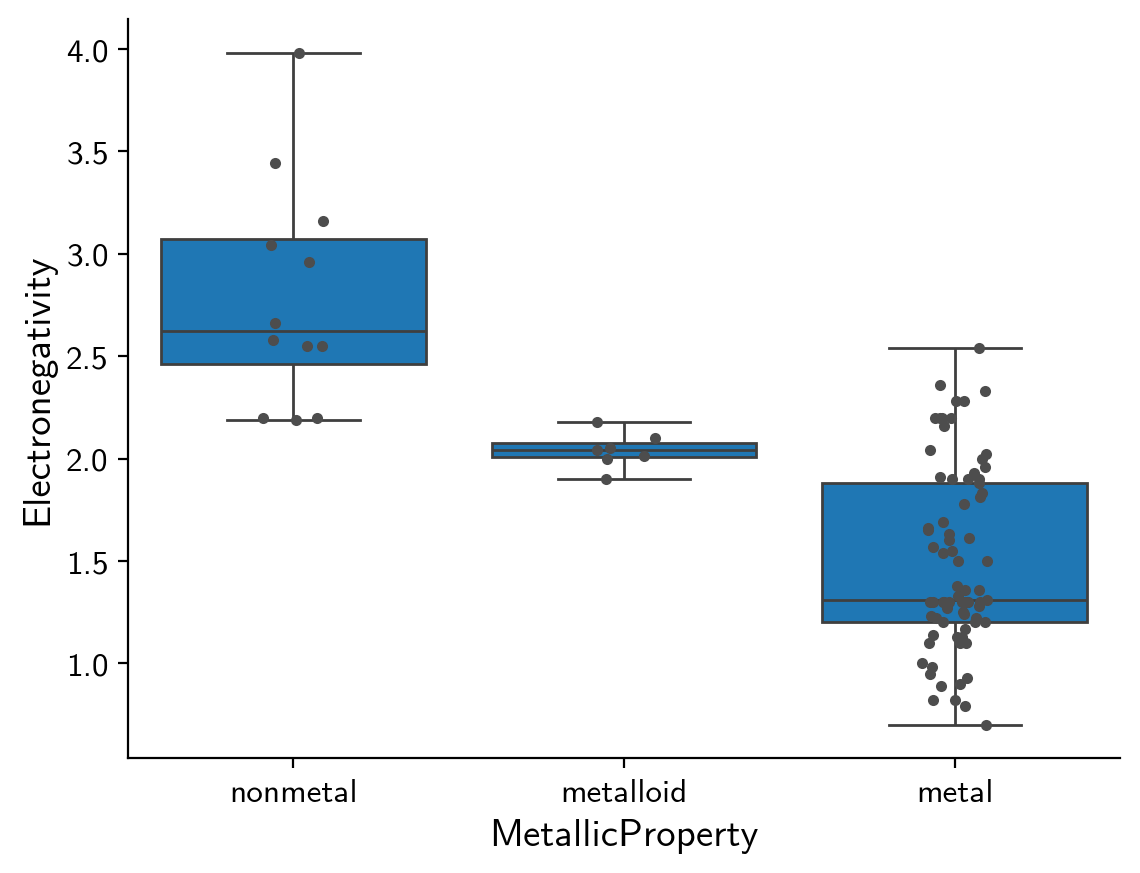

In [20]:
boxorder = ['nonmetal', 'metalloid', 'metal']

sns.boxplot(
    data=df,
    x='MetallicProperty',
    y='Electronegativity',
    order=boxorder,
    whis=[0, 100],
    saturation=1.0,
)

sns.stripplot(
    data=df,
    x='MetallicProperty',
    y='Electronegativity',
    order=boxorder,
    size=4, color=".3", linewidth=0,
)

plt.show()

Altogether, one-dimensional plots enable the investigator to understand the underlying data distributions and formulate hypotheses about their origins. The hypotheses can be tested with statistical methods and represented with distribution plots such as violin or box plots. Finally, using the knowledge of aggregation and combining quantitative with categorical variables, the visualized plots can help extract knowledge from the data.

# Two-dimensional plots

Visualizing distributions alone may not help finding correlations between different quantitative variables. In these cases, plots with higher dimensions of quantitative information may be necessary. In this section, we will showcase visualizations of plots with two quantitative variables, their utility, and how to obtain insights from them. 

## Scatter plots

The simplest way to relate two quantitative variables is through the use of scatter plots. Using positions on x and y axes as encodings for quantitative variables, we obtain plots that relate two variables. These plots may elucidate the presence (or absence) of correlations between the two variables of interest. Scatter plots assume no particular ordering between the data points.

One interesting example is the relationship between the first ionization energy and the Pauling electronegativity of an element. Although the Pauling electronegativity does not use the first ionization energy as an input, it relies on the dissociation energy of chemical bonds. This leads to a correlation between both scales:

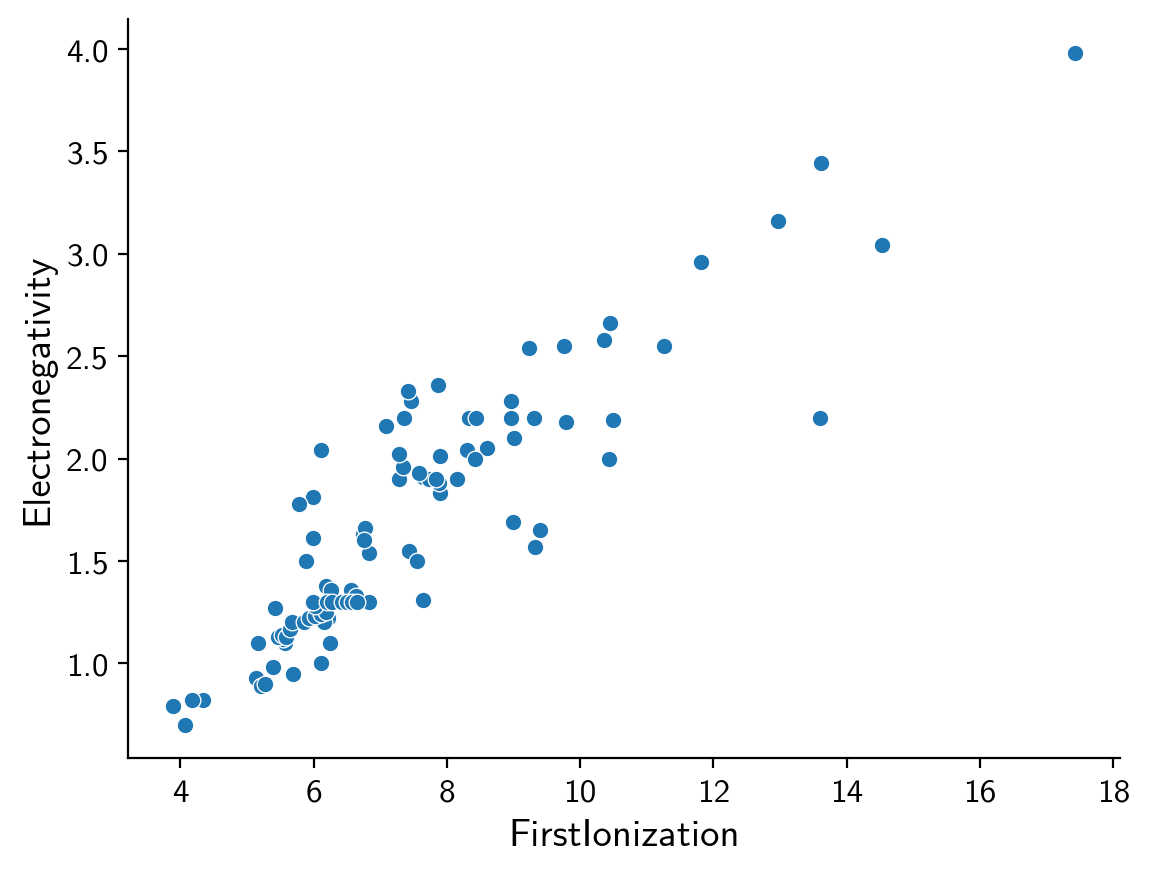

In [21]:
sns.scatterplot(
    data=df,
    x='FirstIonization',
    y='Electronegativity',
)

plt.show()

This two-dimensional graph can be extended to include a categorical variable, encoded in the color of each point. For example, the phase of the compounds can help visualize outliers in the distributions of ionization energy and electronegativity:

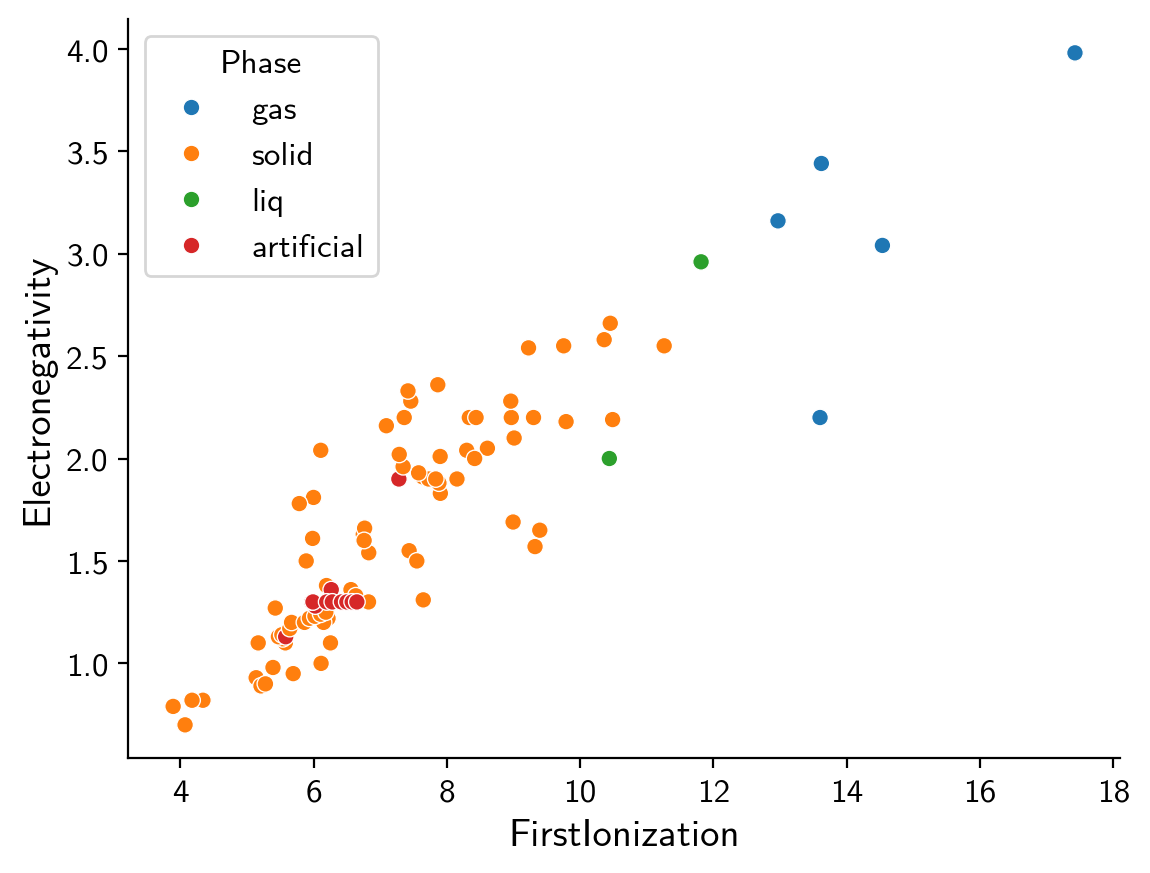

In [22]:
sns.scatterplot(
    data=df,
    x='FirstIonization',
    y='Electronegativity',
    hue='Phase',
)

plt.show()

It becomes clear in this graph that the known compounds high ionization energy are seen in the gas phase in nature.

When more than one variable is available, scatter plots can be used to investigate the correlation between several quantitative variables. This plot can be arranged in a matrix, facilitating its analysis:

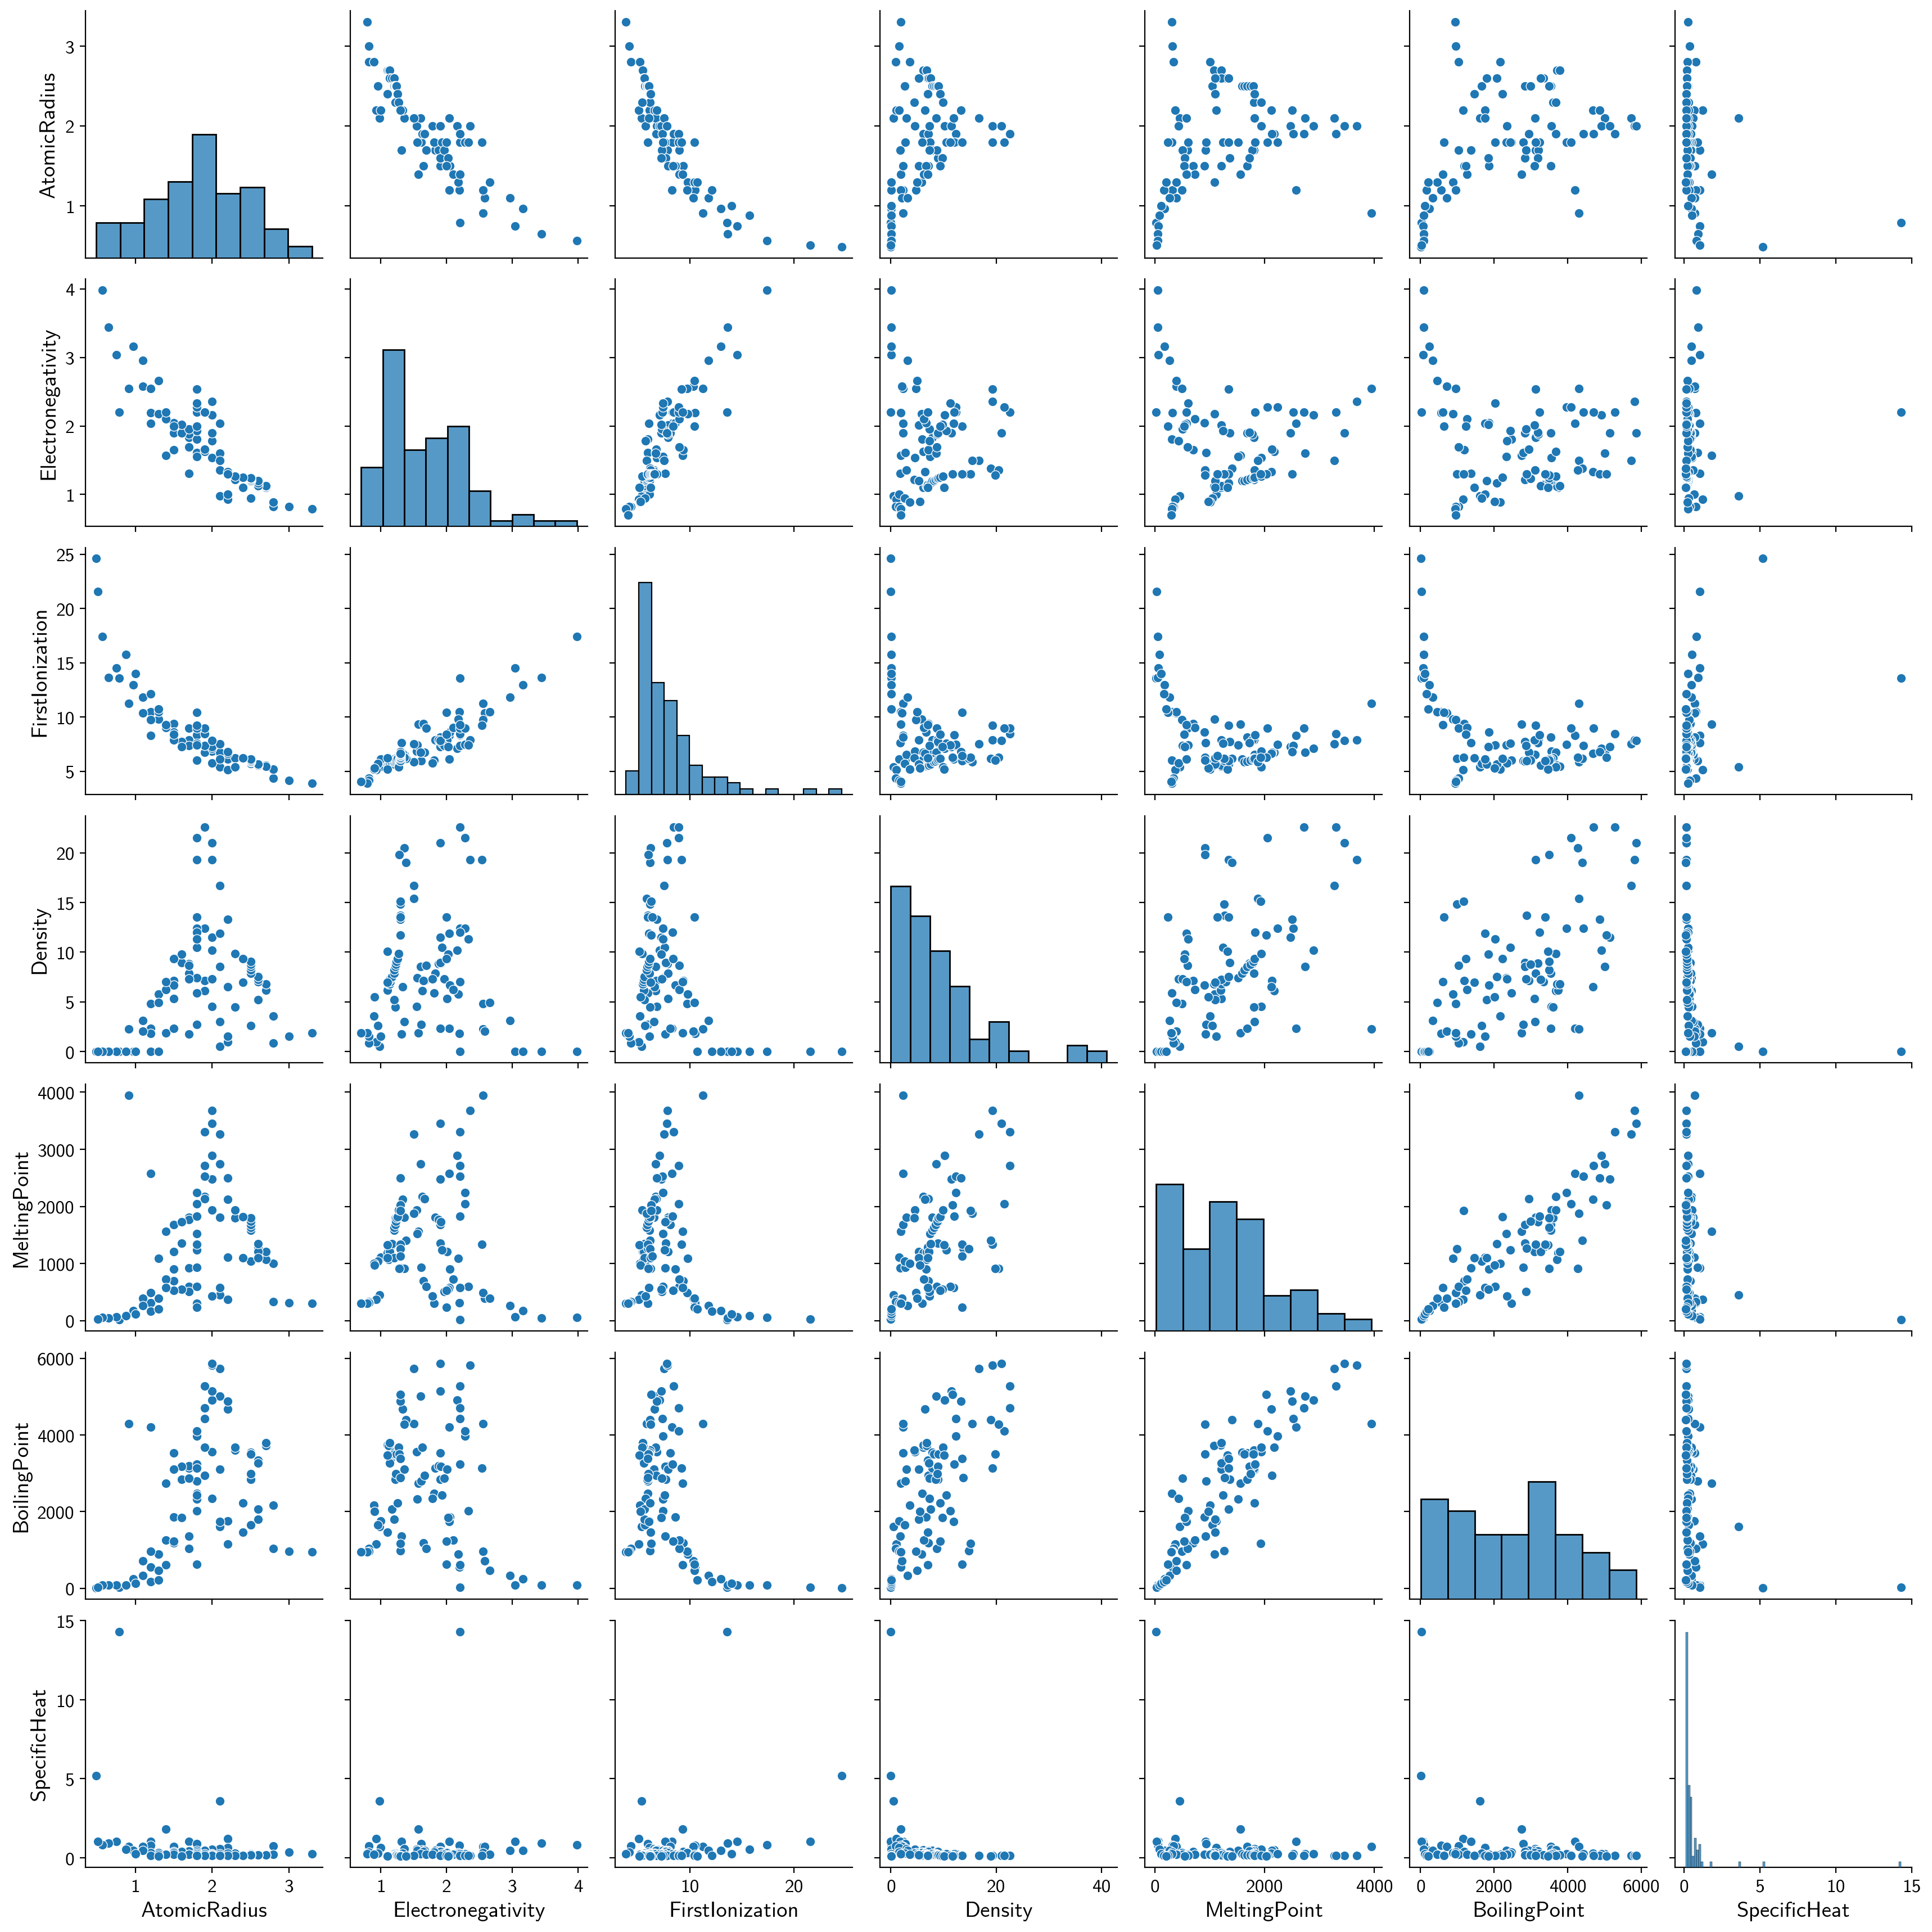

In [23]:
props = ['AtomicRadius', 'Electronegativity', 'FirstIonization', 'Density', 'MeltingPoint',
       'BoilingPoint', 'SpecificHeat']

sns.pairplot(data=df, vars=props)

plt.show()

In the plots above, selected quantitative variables are plotted against each other, avoiding the labor of plotting the variables individually. Because the diagonal elements of the matrix would yield a straight line (any quantity has a perfect correlation with itself), `seaborn` replaces it by a histogram with the distribution of points for that particular quantity.

This analysis showcases several interesting relationships between elemental properties. In addition to the correlation between the ionization energy and the electronegativity, the following observations can be stated: 

- The melting and boiling points are positively correlated
- The electronegativity/ionization energy and atomic radius are negatively correlated

## Line plots

When one of the quantitative variables has an ordering (e.g., time series), a scatter plot can be created in conjunction with a line connecting these points. The line is useful to identifying trends between variables in the dataset. One example is [Lothar Meyer](https://en.wikipedia.org/wiki/Lothar_Meyer)'s discovery of a trend between the elements in the periodic table according to the atomic weight:

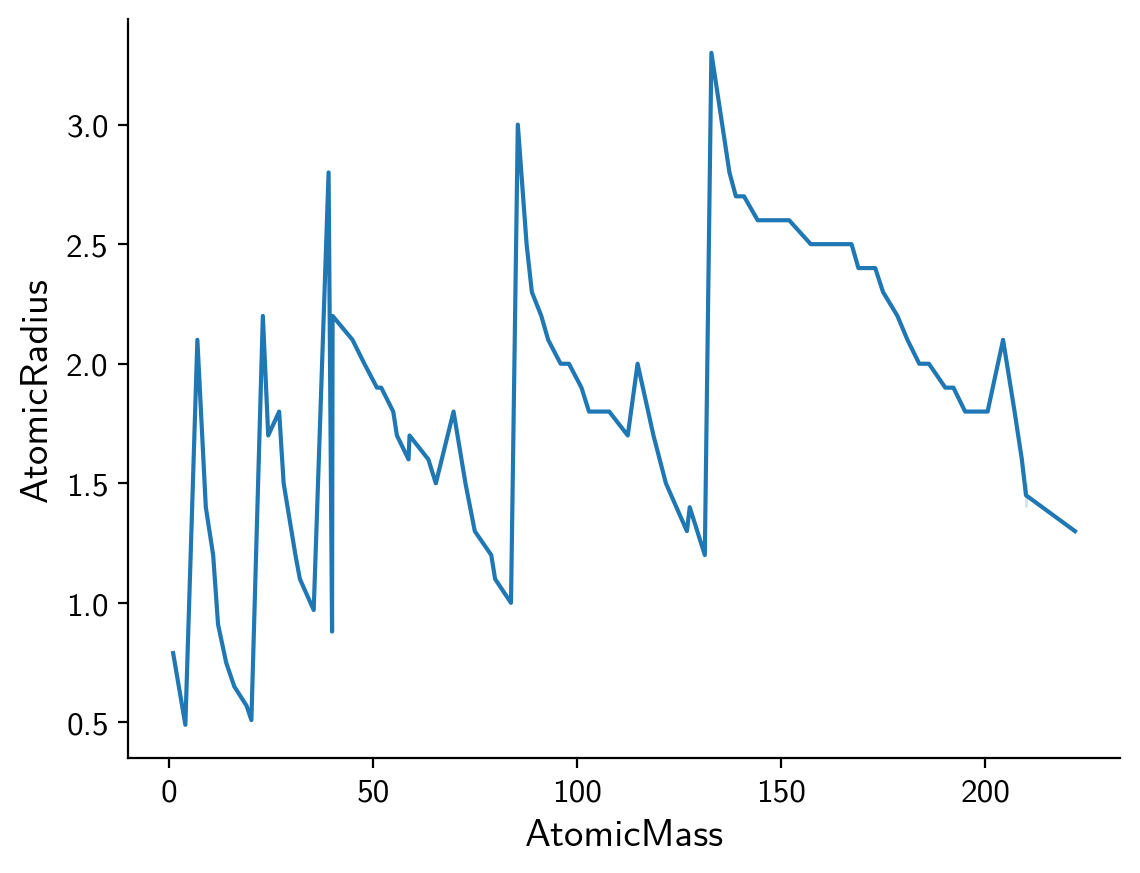

In [24]:
sns.lineplot(data=df, x='AtomicMass', y='AtomicRadius')
plt.show()

This graph enabled Meyer to group elements according to their properties, thus aiding establish the periodic table as one representation of elements.

Similar analyses can be performed including ordinal variables, such as the now-known groups and periods of the element within the periodic table:

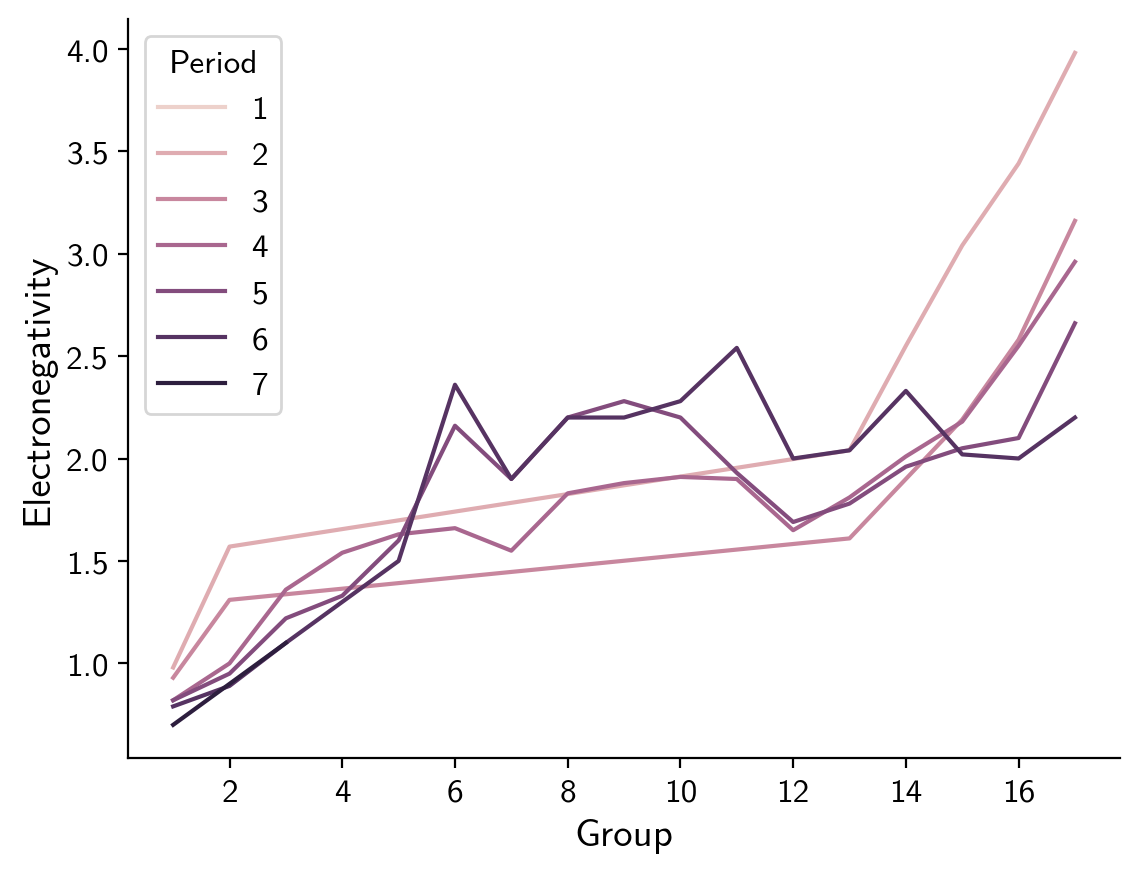

In [25]:
sns.lineplot(data=df, x='Group', y='Electronegativity', hue='Period')

plt.show()

The plot above shows how the electronegativity typically increases as the group increases.

## Stacked area plot

When one of the two quantitative variables to be visualized can be broken down into categories, especially when the categories sum up to a total, a stacked area plot becomes a useful tool. For example, if we wanted to visualize how many elements were discovered since 1700 according to their metallicity, a stacked area plot is one way of showing this data:

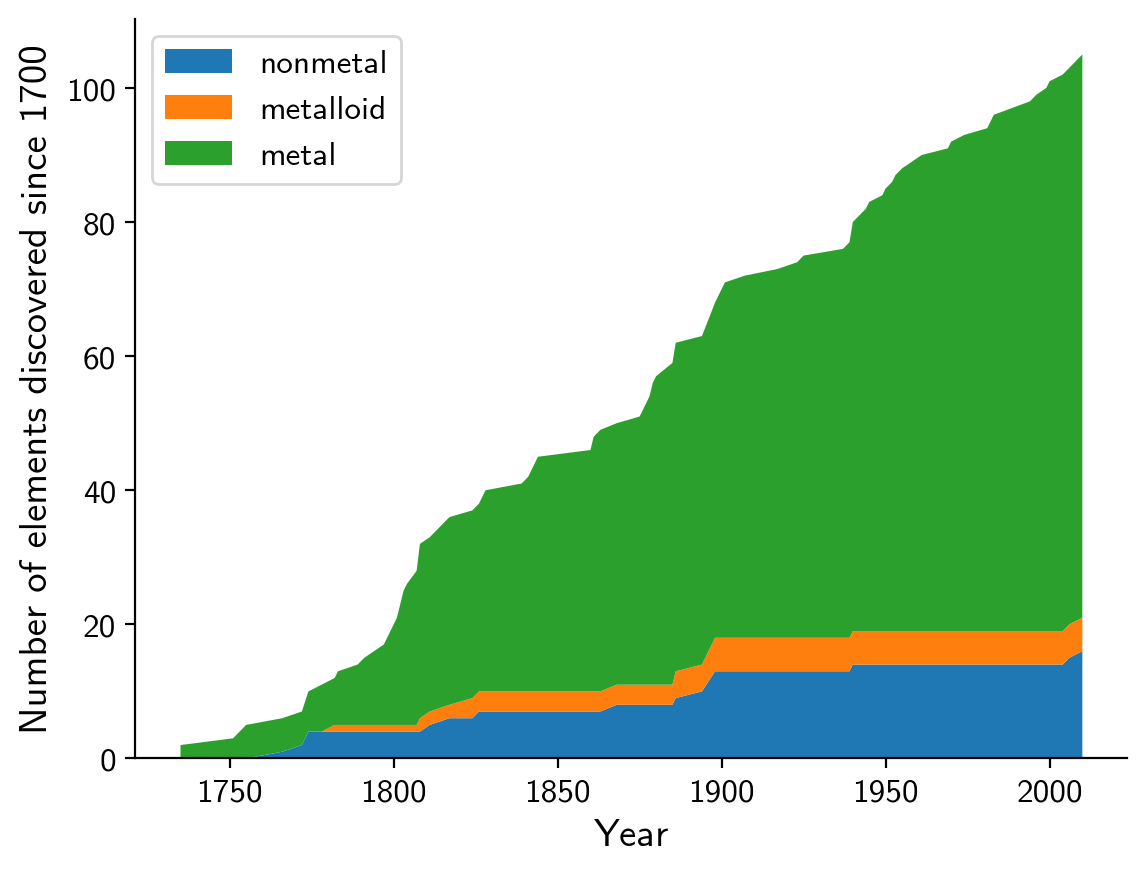

In [26]:
fig, ax = plt.subplots()

yeardf = (df
    .loc[df.Year >= 1700]
    .groupby(['Year', 'MetallicProperty'])
    .count()['AtomicNumber']
    .unstack()
    .fillna(0)
    .cumsum()
)

ax.stackplot(
    yeardf.index,
    yeardf['nonmetal'],
    yeardf['metalloid'],
    yeardf['metal'],
    labels=['nonmetal', 'metalloid', 'metal']
)

ax.set_xlabel('Year')
ax.set_ylabel('Number of elements discovered since 1700')

ax.legend(loc='upper left')
plt.show()

In the graph above, the ratios between the metallic properties of the elements can be easily compared by the relative heights of the plots.

# Three-dimensional plots

In many cases, two dimensions is not enough to fully represent the dataset, where three quantitative variables may be required. Concepts of small multiples may help representing the distribution of data points for two quantitative variables and one nominal/ordinal variable, as shown in the correlation matrix above. However, unless one of the quantitative variables is binned, different encodings may be necessary to represent a three-dimensional data onto a two-dimensional plot. These encodings are usually the size or color of the marker representing the data. Below, a series of examples of visualizations are showcased to represent three-dimensional data.

## Scatter plots with three variables

The most straightforward way to encode three-dimensional data points is to use a 3D scatter plot:

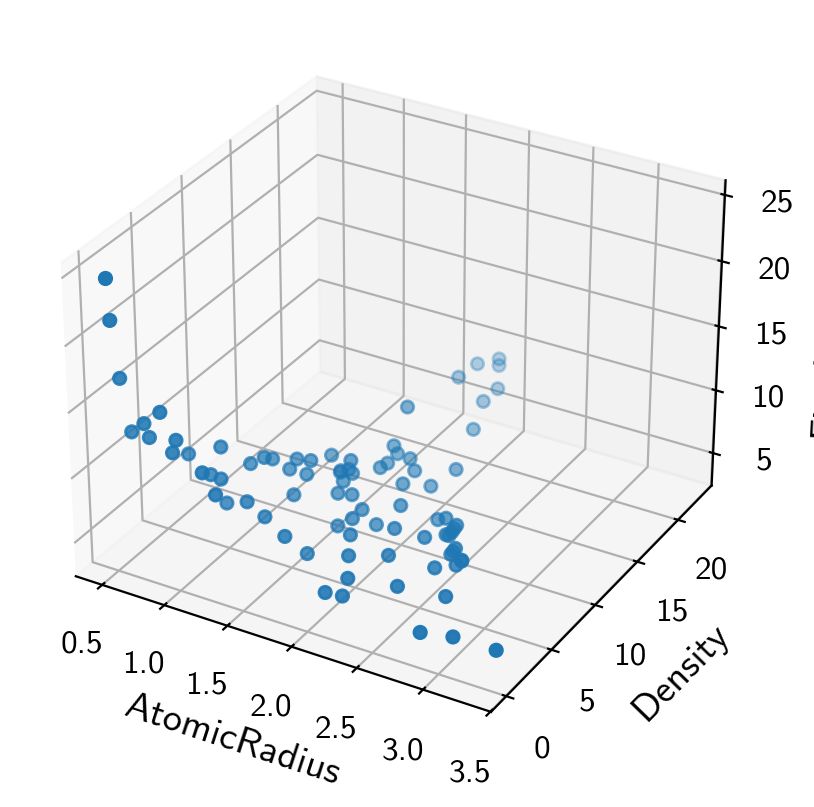

In [27]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

xlab = 'AtomicRadius'
ylab = 'Density'
zlab = 'FirstIonization'

ax.scatter(df[xlab], df[ylab], df[zlab])

ax.set_xlabel(xlab)
ax.set_ylabel(ylab)
ax.set_zlabel(zlab)

plt.show()

Despite useful in interactive visualizations, 3D scatter plots can be hard to interpret in 2D static media, such as in publications. The lack of depth can confuse the reader and make the data ambiguous, unless significant effort is added to curate the plot into an interpretable way.

### Encoding 3D information in marker sizes and colors

Different encodings can be used for translating such 3D data into 2D plots. For example, the size of the marker can be used to encode one of the variables:

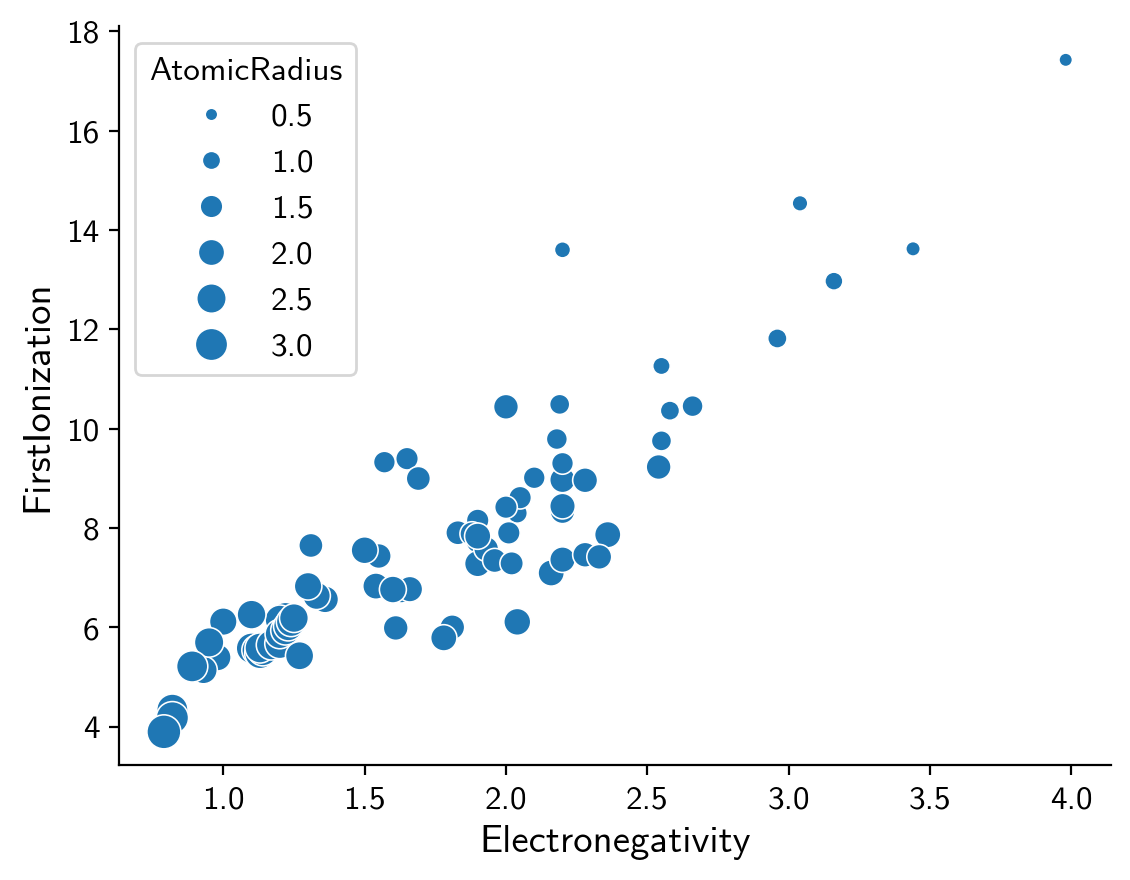

In [28]:
sns.scatterplot(
    data=df,
    x='Electronegativity',
    y='FirstIonization',
    size='AtomicRadius',
    sizes=(20, 150),
)

plt.show()

In the plot above, the atomic radius is mapped to the radius of the marker. Although the size mapping can be somewhat qualitative, given the difficulty of precisely recovering the quantitative variable, it allows insights to be readily extracted from the plot. For example, the correlation of electronegativity and ionization energy has been shown before, but the information of atomic radii shows how smaller radii are usually correlated with higher ionization energies AND electronegativity.

Instead of using sizes, another possibility is to encode the same information onto a color using a continuous scale:

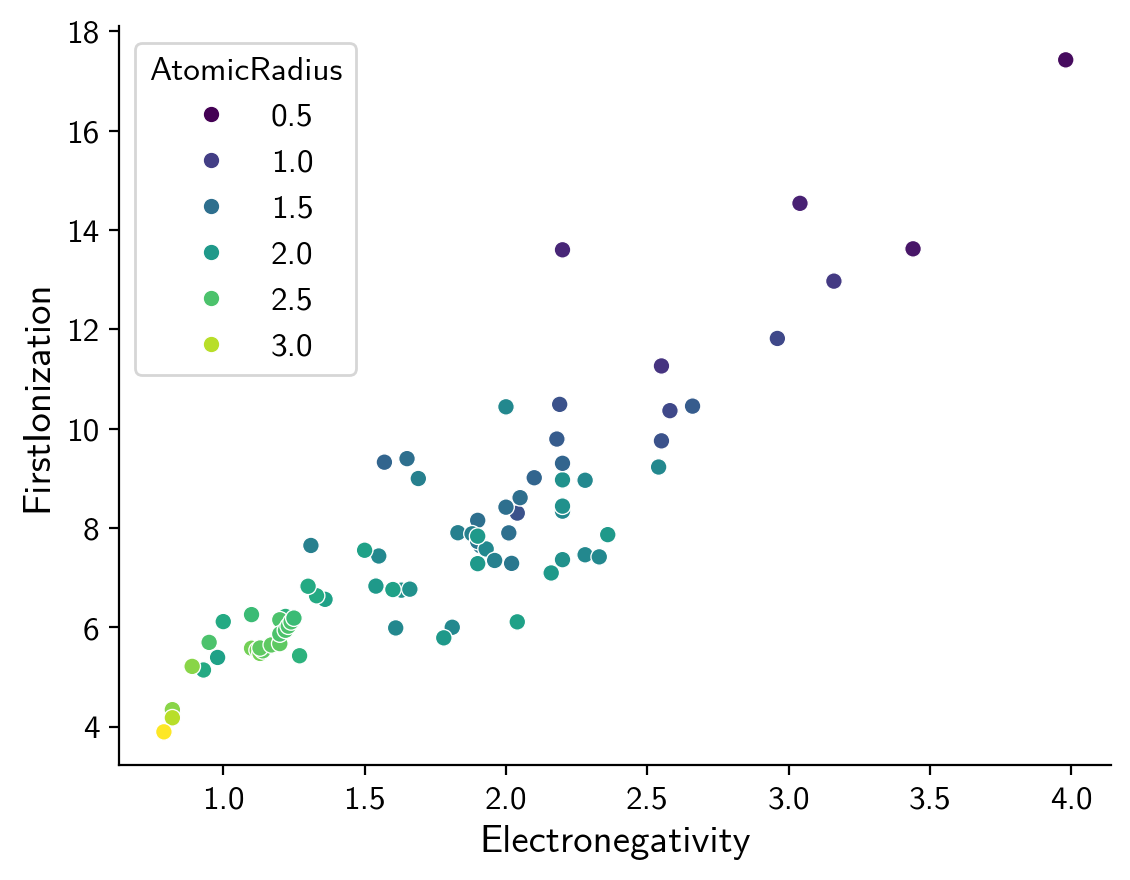

In [29]:
sns.scatterplot(
    data=df,
    x='Electronegativity',
    y='FirstIonization',
    hue='AtomicRadius',
    palette='viridis',
)

plt.show()

When used in combination with an adequate color map, the color scale is a visually appealing way to convey the results. The two encodings can be combined for a reinforced idea of the atomic radius:

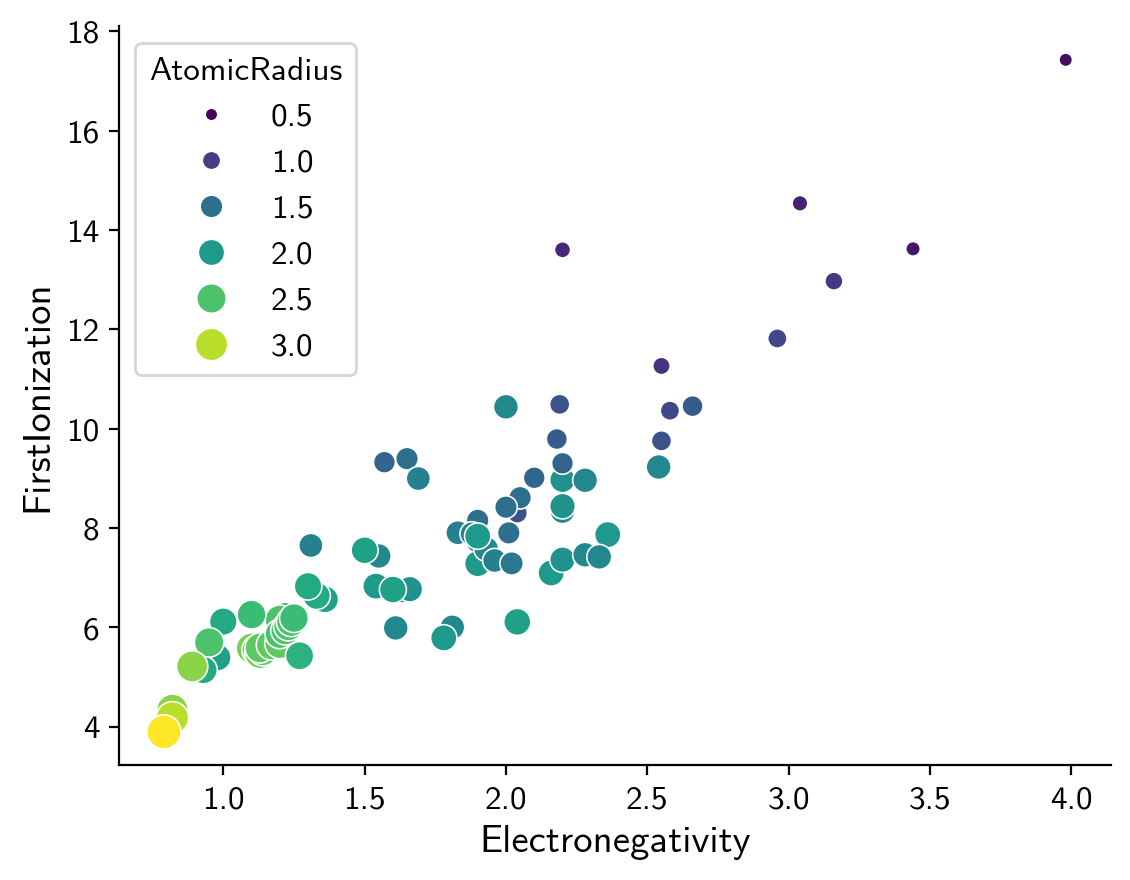

In [30]:
sns.scatterplot(
    data=df,
    x='Electronegativity',
    y='FirstIonization',
    hue='AtomicRadius',
    palette='viridis',
    size='AtomicRadius',
    sizes=(20, 150),
)

plt.show()

Alternatively, the color encoding can be used for a categorical variable, effectively encoding three quantitative variables and one categorical/ordinal variable in the same graph:

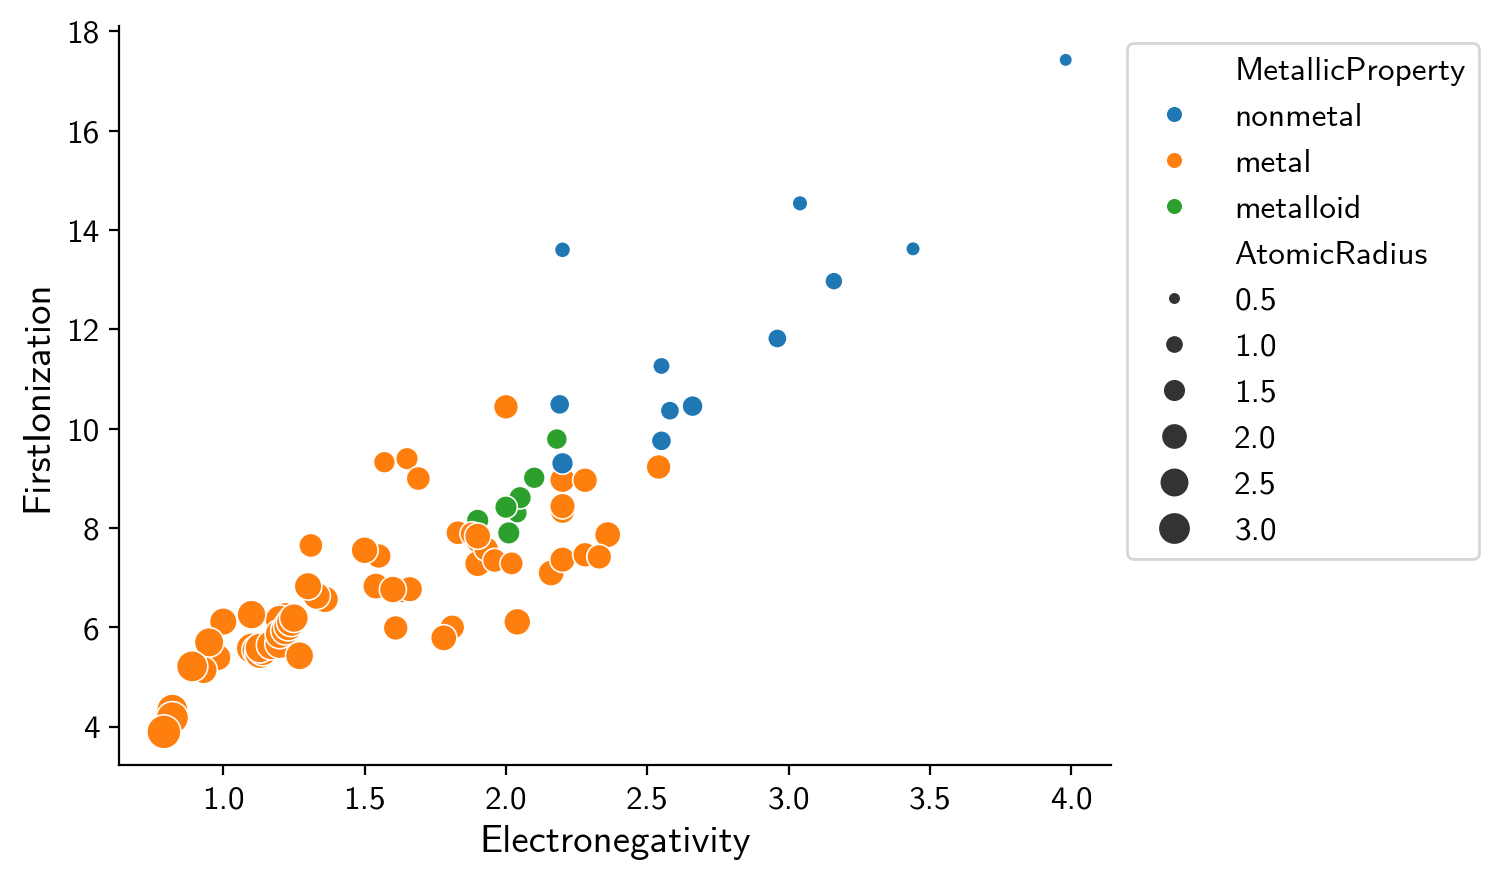

In [31]:
sns.scatterplot(
    data=df,
    x='Electronegativity',
    y='FirstIonization',
    hue='MetallicProperty',
    size='AtomicRadius',
    sizes=(20, 150),
)

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

## Heatmaps

Whereas a scatter plot does not necessarily impose an implicit relation between the variables and is often used in exploratory data analysis, a heatmap assumes that one quantitative variable is a function of two other variables, which are categorical, ordinal, or quantitative. The dependent variable is usually encoded using a color scale, and the independent variables are either encoded as rows/columns of a matrix when the variables are discrete, or as axes of a plot, when the variables are continuous.

For example, properties of the periodic table can be easily represented using a heatmap. Not considering the f-block elements, the boiling point of the elements can be visualized using colors as follows:

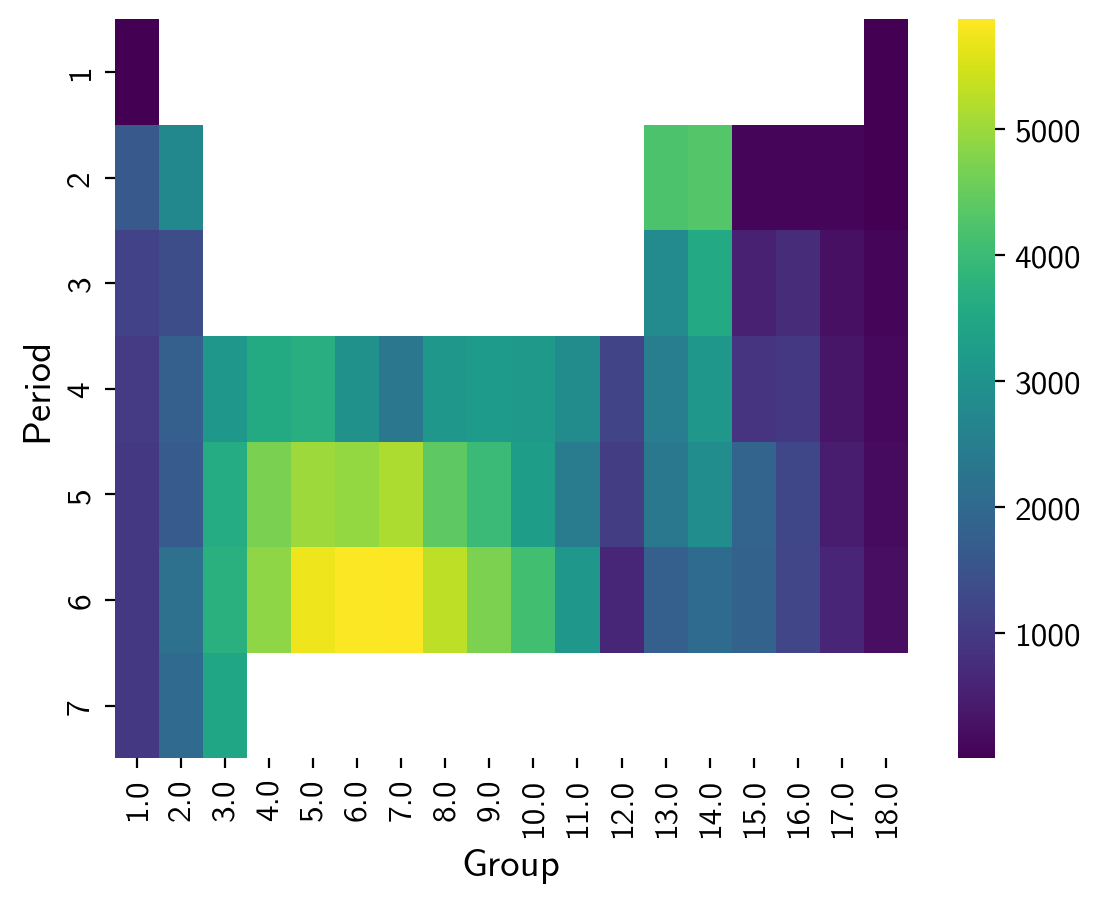

In [32]:
data = df.groupby(['Period', 'Group'])['BoilingPoint'].first().unstack()

ax = sns.heatmap(data, cmap='viridis')

plt.show()

Whenever the two independent variables are continuous, however, it becomes convenient to bin the space into hexagons, which partition the space into equally sized and spaced tiles. For example, a 3D histogram can be created by binning the space and counting how many data points fall within the bin. Then, the dependent variable (count) is encoded with a color:

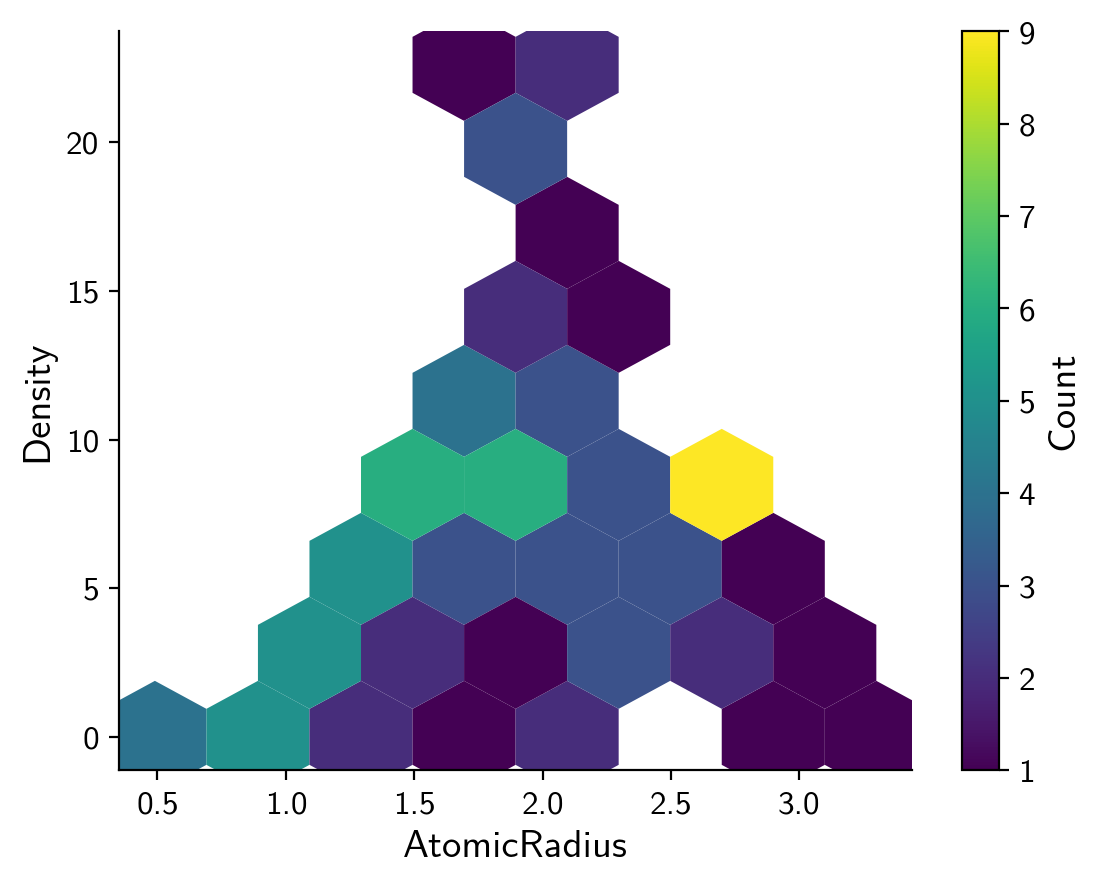

In [33]:
fig, ax = plt.subplots()

x = 'AtomicRadius'
y = 'Density'

hb = ax.hexbin(
    df[x],
    df[y],
    mincnt=1,
    gridsize=7,
    cmap='viridis',
    linewidths=(0.,),
)

cbar = fig.colorbar(hb)
cbar.set_label('Count')

ax.set_xlabel(x)
ax.set_ylabel(y)

plt.show()

This two-dimensional histogram is particularly useful when hundreds to thousands points fall within the same area. In this case, such hexbin plot conveys the two-dimensional distribution of points instead of relying on the marginal distribution. At such big-data regimes, it is also more informative than scatter plots, which cannot show the density of points per area.

This distribution plot can also aggregate information from a different variable instead of simply counting the number of points within certain hexagons. For example, the average atomic mass of the elements falling within the area can be used to obtain insights from the dataset:

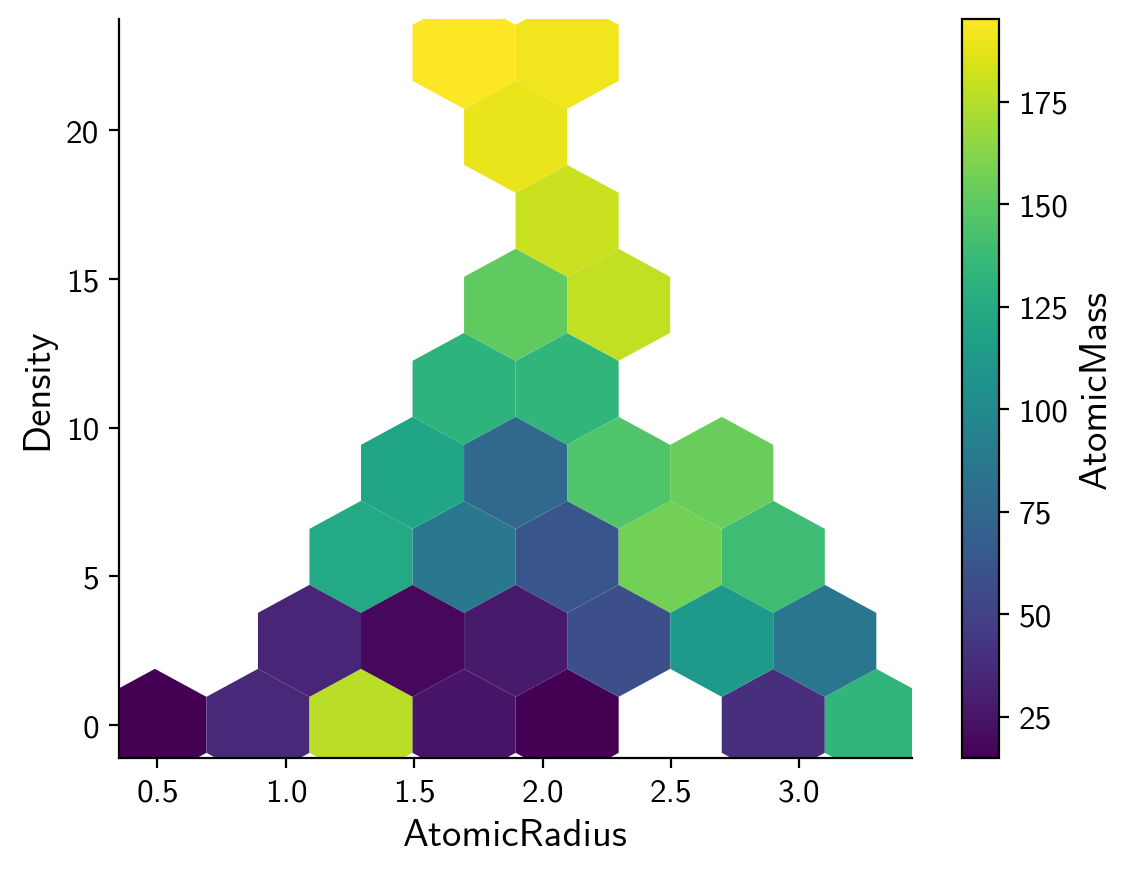

In [34]:
fig, ax = plt.subplots()

x = 'AtomicRadius'
y = 'Density'
C = 'AtomicMass'

hb = ax.hexbin(
    df[x],
    df[y],
    mincnt=1,
    gridsize=7,
    cmap='viridis',
    linewidths=(0.,),
    C=df[C],
    reduce_C_function=np.mean,
)

cbar = fig.colorbar(hb)
cbar.set_label(C)

ax.set_xlabel(x)
ax.set_ylabel(y)

plt.show()

The visualization recovers the idea that, for a given atomic radius, a higher density usually requires a higher atomic mass.